# Generate Overall Satisfaction Labels

**Thesis project:** Explainable Multi-modal Deep Learning System for Product Quality Assessment using Image and Text Data

## Purpose

This notebook derives a new, fully-explainable target label — **`overall_satisfaction`** — for every
review in the cleaned Foody dataset (`data_raw/reviews_clean.csv` / `.json`, 9,946 rows).

`overall_satisfaction` represents the reviewer's **overall** experience, separate from the four
per-aspect scores (food, service, atmosphere, price). It is computed as:

```
avg_rating          = mean(food_score, service_score, atmosphere_score, price_score)   # 4 aspects, position_score EXCLUDED
overall_adjustment  = sum(score of every triggered global-satisfaction rule)
overall_satisfaction = clip(avg_rating + overall_adjustment, 0, 10)
```

## Key design decisions

1. **`position_score` is preserved but excluded** from `avg_rating`, from rule generation, and from
   `overall_satisfaction`. It remains in the dataset for traceability and is analysed separately in
   Section 16.
2. **The original Foody rating is preserved** as `foody_original_avg_rating` before `avg_rating` is
   recomputed from the 4 remaining aspects.
3. **Rules are data-driven**: all 14 rule categories live in `data_processed/overall_satisfaction_rules.json`
   and are *loaded dynamically* by the rule engine (Section 9) — nothing is hardcoded in the engine code.
4. **Every adjustment is explainable**: each review gets an `overall_evidence` record listing exactly
   which rule(s) fired, on which matched text span(s), and with what score contribution.
5. **No randomness** is used to generate scores. `RANDOM_SEED = 42` is set only for reproducible
   ordering/sampling (e.g., the audit sample in Section 15).

## Inputs

- `data_raw/reviews_clean.csv`, `data_raw/reviews_clean.json` (9,946 rows x 40 columns, read-only — never modified)

## Outputs (written to `data_processed/`, originals are never overwritten)

- `overall_satisfaction_rules.json` — the 14 rule categories (score, description, regex patterns)
- `reviews_clean_enhanced.csv` — original 40 columns + new columns (CSV, nested fields as JSON strings)
- `reviews_clean_enhanced.json` — same data, nested fields as native JSON arrays/objects
- `overall_satisfaction_rule_analysis.md` — rule documentation + coverage/validity report generated from real results

## Libraries

Python standard library (`json`, `re`, `unicodedata`, `pathlib`, `collections`) plus `pandas`, `numpy`,
and `matplotlib` only.


## Section 1 — Environment Setup

Imports, reproducibility seed, display options, and the directory/file layout used throughout the
notebook. `data_processed/` is created if it does not already exist.

In [1]:
import json
import re
import unicodedata
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# --- Directory layout -------------------------------------------------
RAW_DIR = Path('../data_raw')
PROC_DIR = Path('../data_processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = RAW_DIR / 'reviews_clean.csv'
JSON_PATH = RAW_DIR / 'reviews_clean.json'

RULES_PATH = PROC_DIR / 'overall_satisfaction_rules.json'
OUT_CSV_PATH = PROC_DIR / 'reviews_clean_enhanced.csv'
OUT_JSON_PATH = PROC_DIR / 'reviews_clean_enhanced.json'
ANALYSIS_MD_PATH = PROC_DIR / 'overall_satisfaction_rule_analysis.md'

# --- Column groups used repeatedly ------------------------------------
ASPECT_COLS_4 = ['food_score', 'service_score', 'atmosphere_score', 'price_score']
ASPECT_COLS_ALL = ASPECT_COLS_4 + ['position_score']

RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()

print(f"Random seed       : {RANDOM_SEED}")
print(f"Run timestamp (UTC): {RUN_TIMESTAMP}")
print(f"Raw data dir       : {RAW_DIR.resolve()}")
print(f"Output dir         : {PROC_DIR.resolve()}")
print(f"4-aspect columns   : {ASPECT_COLS_4}")
print(f"All aspect columns : {ASPECT_COLS_ALL}")


Random seed       : 42
Run timestamp (UTC): 2026-06-13T07:26:05.628291+00:00
Raw data dir       : D:\SE365\data_raw
Output dir         : D:\SE365\data_processed
4-aspect columns   : ['food_score', 'service_score', 'atmosphere_score', 'price_score']
All aspect columns : ['food_score', 'service_score', 'atmosphere_score', 'price_score', 'position_score']


## Section 2 — Load and Understand Dataset

We load **both** `reviews_clean.csv` and `reviews_clean.json`, verify they are consistent, and produce
a **Dataset Understanding Report** covering shape, schema, missing values, duplicates, and the
relationship between `avg_rating` and the 5 aspect scores. This report is produced *before* any
transformation logic so that every later decision (Section 4 onward) is grounded in the real data.

In [2]:
df_raw = pd.read_csv(CSV_PATH)

with open(JSON_PATH, encoding='utf-8') as f:
    json_records = json.load(f)
df_json = pd.DataFrame(json_records)

print(f"CSV  shape : {df_raw.shape}")
print(f"JSON shape : {df_json.shape}")
print(f"\nCSV columns ({len(df_raw.columns)}):")
for i, c in enumerate(df_raw.columns):
    print(f"  [{i:2d}] {c:30s} {str(df_raw[c].dtype):10s}")


CSV  shape : (9946, 40)
JSON shape : (9946, 40)

CSV columns (40):
  [ 0] review_id                      int64     
  [ 1] restaurant_id                  int64     
  [ 2] restaurant_name                str       
  [ 3] user_id                        int64     
  [ 4] user_name                      str       
  [ 5] user_avatar_url                str       
  [ 6] title                          str       
  [ 7] comment                        str       
  [ 8] avg_rating                     float64   
  [ 9] food_score                     float64   
  [10] service_score                  float64   
  [11] atmosphere_score               float64   
  [12] position_score                 float64   
  [13] price_score                    float64   
  [14] review_type                    float64   
  [15] review_type_name               float64   
  [16] created_date_raw               str       
  [17] created_on                     str       
  [18] updated_on                     str       
  

### 2.1 CSV vs JSON consistency check

Both files describe the same 9,946 reviews and should agree on `review_id` membership and on the
values of every shared column.

In [3]:
same_ids = set(df_raw['review_id']) == set(df_json['review_id'])
print(f"Same review_id set in CSV and JSON: {same_ids}")
assert same_ids, "CSV and JSON describe different sets of reviews"

common_cols = [c for c in df_raw.columns if c in df_json.columns]
csv_sorted = df_raw.sort_values('review_id').reset_index(drop=True)
json_sorted = df_json.sort_values('review_id').reset_index(drop=True)

# Columns stored as ISO-8601 strings in JSON but as pandas datetime strings in CSV.
DATETIME_COLS = {'created_on', 'updated_on', 'created_datetime', 'updated_datetime'}

mismatches = {}
mismatch_examples = {}
for col in common_cols:
    a, b = csv_sorted[col], json_sorted[col]
    if col in DATETIME_COLS:
        a_val = pd.to_datetime(a, errors='coerce', utc=True, format='mixed')
        b_val = pd.to_datetime(b, errors='coerce', utc=True, format='mixed')
        eq = (a_val == b_val) | (a_val.isna() & b_val.isna())
    elif pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        eq = np.isclose(a.fillna(-999999), b.fillna(-999999)) | (a.isna() & b.isna())
    else:
        # Treat NaN (CSV) and None/'' (JSON) as the same "missing" value before comparing.
        a_norm = a.where(a.notna(), '').astype(str).replace({'nan': '', 'None': '', 'NaT': ''})
        b_norm = b.where(b.notna(), '').astype(str).replace({'nan': '', 'None': '', 'NaT': ''})
        eq = (a_norm == b_norm)
    n_bad = int((~eq).sum())
    if n_bad:
        mismatches[col] = n_bad
        idx = np.where(~eq)[0][:2]
        mismatch_examples[col] = [(a.iloc[i], b.iloc[i]) for i in idx]

print(f"Columns compared          : {len(common_cols)}")
print(f"Columns with real mismatches: {len(mismatches)}")
if mismatches:
    for col, n in mismatches.items():
        print(f"  {col}: {n} rows differ, e.g. {mismatch_examples[col]}")
else:
    print("=> CSV and JSON are fully consistent across all shared columns")
    print("   (after normalizing NaN/None/empty-string and datetime string formats,")
    print("    which differ only in representation between pandas read_csv and json.load).")


Same review_id set in CSV and JSON: True


Columns compared          : 40
Columns with real mismatches: 0
=> CSV and JSON are fully consistent across all shared columns
   (after normalizing NaN/None/empty-string and datetime string formats,
    which differ only in representation between pandas read_csv and json.load).


### 2.2 Missing values, duplicates, and row-level integrity

In [4]:
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
if len(missing):
    print(missing.to_string())
else:
    print("  (none)")

print(f"\nDuplicate review_id      : {df_raw['review_id'].duplicated().sum()}")
print(f"Fully duplicated rows     : {df_raw.duplicated().sum()}")
print(f"Unique restaurant_id count: {df_raw['restaurant_id'].nunique()}")


Columns with missing values:
review_type_name    9946
user_avatar_url     9945
updated_datetime    1481
device_name          531
price_score            3
food_score             3
service_score          3
atmosphere_score       3
position_score         3
title                  2
review_type            1
created_on             1
updated_on             1
created_datetime       1
created_year           1
created_month          1

Duplicate review_id      : 0
Fully duplicated rows     : 0
Unique restaurant_id count: 298


### 2.3 Rating and aspect-score relationship

The dataset's original `avg_rating` should equal the mean of all 5 aspect scores
(`food_score`, `service_score`, `atmosphere_score`, `price_score`, `position_score`).

In [5]:
print(df_raw[ASPECT_COLS_ALL + ['avg_rating']].describe().T)

mean5 = df_raw[ASPECT_COLS_ALL].mean(axis=1)
diff5 = (df_raw['avg_rating'] - mean5).abs()
print(f"\nMax |avg_rating - mean(5 aspects)| (ignoring NaN rows): {diff5.max():.6f}")
print(f"Rows where diff > 1e-6 (excluding NaN)                : {(diff5 > 1e-6).sum()}")

nan_aspect_mask = df_raw[ASPECT_COLS_ALL].isna().all(axis=1)
print(f"\nRows where ALL 5 aspect scores are NaN: {nan_aspect_mask.sum()}")
print(df_raw.loc[nan_aspect_mask, ['review_id', 'avg_rating'] + ASPECT_COLS_ALL])


                     count   mean    std    min    25%    50%    75%     max
food_score       9943.0000 6.9147 2.9035 1.0000 5.0000 8.0000 9.0000 10.0000
service_score    9943.0000 6.5599 2.8523 1.0000 5.0000 7.0000 9.0000 10.0000
atmosphere_score 9943.0000 6.6196 2.4674 1.0000 5.0000 7.0000 8.0000 10.0000
price_score      9943.0000 6.6660 2.6241 1.0000 5.0000 7.0000 8.0000 10.0000
position_score   9943.0000 7.0175 2.3807 1.0000 5.0000 7.0000 9.0000 10.0000
avg_rating       9946.0000 6.7544 2.4138 0.0000 5.4000 7.2000 8.4000 10.0000

Max |avg_rating - mean(5 aspects)| (ignoring NaN rows): 0.000000
Rows where diff > 1e-6 (excluding NaN)                : 0

Rows where ALL 5 aspect scores are NaN: 3
      review_id  avg_rating  food_score  service_score  atmosphere_score  price_score  position_score
6558    2135710      9.0000         NaN            NaN               NaN          NaN             NaN
7891    2185075      0.0000         NaN            NaN               NaN          NaN     

### 2.4 Dataset Understanding Report — Summary

Consolidated findings that drive every design decision from Section 4 onward.

In [6]:
n_rows, n_cols = df_raw.shape
n_nan_aspect = int(nan_aspect_mask.sum())
n_mismatch = len(mismatches)

print("=" * 78)
print("DATASET UNDERSTANDING REPORT")
print("=" * 78)
print(f"Rows x Columns                 : {n_rows} x {n_cols}")
print(f"CSV/JSON consistency           : {'OK - identical' if n_mismatch == 0 else f'{n_mismatch} mismatched columns'}")
print(f"Duplicate review_id            : {df_raw['review_id'].duplicated().sum()}")
print(f"Fully duplicated rows           : {df_raw.duplicated().sum()}")
print(f"avg_rating == mean(5 aspects)  : confirmed for {n_rows - n_nan_aspect}/{n_rows} rows")
print(f"Rows with all 5 aspects NaN     : {n_nan_aspect} "
      f"(review_id = {df_raw.loc[nan_aspect_mask, 'review_id'].tolist()})")
print(f"avg_rating range                : [{df_raw['avg_rating'].min()}, {df_raw['avg_rating'].max()}]")
print(f"Text field used for rules        : 'comment_clean'")
print(f"Empty/NaN 'comment_clean'        : {df_raw['comment_clean'].isna().sum()}")
print("=" * 78)
print("IMPLICATIONS FOR THIS NOTEBOOK")
print("-" * 78)
print("1. avg_rating in the raw data is the mean of ALL 5 aspects (incl. position_score).")
print("   Section 4 recomputes avg_rating from the 4 NON-position aspects only, and")
print(f"   preserves the original value as 'foody_original_avg_rating'.")
print(f"2. {n_nan_aspect} rows have no aspect scores at all -> the 4-aspect mean is NaN for")
print("   these rows. Section 4 falls back to 'foody_original_avg_rating' for these rows")
print("   and flags them with a boolean 'avg_rating_recomputed' column.")
print("3. CSV and JSON are interchangeable as inputs; this notebook reads the CSV and")
print("   exports both CSV and JSON for the enhanced dataset.")
print("=" * 78)


DATASET UNDERSTANDING REPORT
Rows x Columns                 : 9946 x 40
CSV/JSON consistency           : OK - identical
Duplicate review_id            : 0
Fully duplicated rows           : 0
avg_rating == mean(5 aspects)  : confirmed for 9943/9946 rows
Rows with all 5 aspects NaN     : 3 (review_id = [2135710, 2185075, 1336959])
avg_rating range                : [0.0, 10.0]
Text field used for rules        : 'comment_clean'
Empty/NaN 'comment_clean'        : 0
IMPLICATIONS FOR THIS NOTEBOOK
------------------------------------------------------------------------------
1. avg_rating in the raw data is the mean of ALL 5 aspects (incl. position_score).
   Section 4 recomputes avg_rating from the 4 NON-position aspects only, and
   preserves the original value as 'foody_original_avg_rating'.
2. 3 rows have no aspect scores at all -> the 4-aspect mean is NaN for
   these rows. Section 4 falls back to 'foody_original_avg_rating' for these rows
   and flags them with a boolean 'avg_rating_rec

## Section 3 — Rating and Aspect Analysis

Before restructuring, we examine how `position_score` relates to `avg_rating` and to the other
4 aspects, and preview the effect of excluding it from the average. This analysis directly motivates
the restructuring in Section 4 and is revisited with full statistics in Section 16.

In [7]:
corr = df_raw[ASPECT_COLS_ALL + ['avg_rating']].corr().round(3)
print("Correlation matrix (aspects x avg_rating):")
print(corr)

print("\nCorrelation of avg_rating with each aspect:")
print(corr['avg_rating'].drop('avg_rating').sort_values(ascending=False))


Correlation matrix (aspects x avg_rating):
                  food_score  service_score  atmosphere_score  price_score  position_score  avg_rating
food_score            1.0000         0.8350            0.7600       0.8280          0.7560      0.9230
service_score         0.8350         1.0000            0.8110       0.7910          0.7620      0.9260
atmosphere_score      0.7600         0.8110            1.0000       0.7520          0.8080      0.9030
price_score           0.8280         0.7910            0.7520       1.0000          0.7690      0.9100
position_score        0.7560         0.7620            0.8080       0.7690          1.0000      0.8920
avg_rating            0.9230         0.9260            0.9030       0.9100          0.8920      1.0000

Correlation of avg_rating with each aspect:
service_score      0.9260
food_score         0.9230
price_score        0.9100
atmosphere_score   0.9030
position_score     0.8920
Name: avg_rating, dtype: float64


In [8]:
avg4_preview = df_raw[ASPECT_COLS_4].mean(axis=1)
diff_preview = df_raw['avg_rating'] - avg4_preview

print("Preview: avg_rating (original, 5-aspect mean) vs mean(4 aspects, excluding position_score)")
print(diff_preview.describe())

n_changed = (diff_preview.abs() > 1e-9).sum()
print(f"\nRows whose rating would change if position_score is excluded: "
      f"{n_changed} / {len(df_raw)} ({100*n_changed/len(df_raw):.2f}%)")
print(f"Mean absolute change: {diff_preview.abs().mean():.4f} (on a 0-10 scale)")


Preview: avg_rating (original, 5-aspect mean) vs mean(4 aspects, excluding position_score)
count   9943.0000
mean       0.0655
std        0.2780
min       -1.3500
25%       -0.0500
50%        0.0000
75%        0.2000
max        1.8000
dtype: float64

Rows whose rating would change if position_score is excluded: 7059 / 9946 (70.97%)
Mean absolute change: 0.1840 (on a 0-10 scale)


### 3.1 Rating distribution buckets (original `avg_rating`)

In [9]:
bins = [0, 2, 4, 6, 8, 10.0001]
labels = ['0-2', '2-4', '4-6', '6-8', '8-10']
bucket_counts = pd.cut(df_raw['avg_rating'], bins=bins, labels=labels, right=False, include_lowest=True).value_counts().sort_index()
print("avg_rating distribution buckets:")
print(bucket_counts)
print(f"\nMean: {df_raw['avg_rating'].mean():.3f}  Median: {df_raw['avg_rating'].median():.3f}  Std: {df_raw['avg_rating'].std():.3f}")


avg_rating distribution buckets:
avg_rating
0-2      663
2-4      770
4-6     1331
6-8     3535
8-10    3647
Name: count, dtype: int64

Mean: 6.754  Median: 7.200  Std: 2.414


## Section 4 — Dataset Restructuring

We now build the working dataframe `df` (a copy of `df_raw`) with the following changes:

1. **Preserve** the original Foody rating in a new column `foody_original_avg_rating`.
2. **Recompute** `avg_rating` as the mean of the 4 non-position aspects
   (`food_score`, `service_score`, `atmosphere_score`, `price_score`).
3. For the 3 rows where all aspect scores are `NaN`, the 4-aspect mean is undefined — these rows
   **fall back** to `foody_original_avg_rating`, and a new boolean column `avg_rating_recomputed`
   records whether the fallback was used (`False`) or the 4-aspect mean was used (`True`).
4. `position_score` is **kept unchanged** in the dataframe for traceability, but is **not** used in
   any computation in this notebook from this point on.

In [10]:
df = df_raw.copy()

# 1. Preserve original Foody rating
df['foody_original_avg_rating'] = df['avg_rating']

# 2. Recompute avg_rating from the 4 non-position aspects
avg4 = df[ASPECT_COLS_4].mean(axis=1)

# 3. Fallback for rows with no aspect scores at all
df['avg_rating_recomputed'] = avg4.notna()
df['avg_rating'] = avg4.where(avg4.notna(), df['foody_original_avg_rating'])

# 4. position_score is untouched (still present in df, unused downstream)
assert 'position_score' in df.columns

n_recomputed = int(df['avg_rating_recomputed'].sum())
n_fallback = int((~df['avg_rating_recomputed']).sum())
print(f"avg_rating recomputed from 4 aspects : {n_recomputed} / {len(df)}")
print(f"avg_rating fell back to Foody original: {n_fallback} / {len(df)}")
print(f"\nFallback rows:")
print(df.loc[~df['avg_rating_recomputed'], ['review_id', 'foody_original_avg_rating', 'avg_rating'] + ASPECT_COLS_ALL])

assert df['avg_rating'].isna().sum() == 0, "avg_rating must not contain NaN after restructuring"
assert df['avg_rating'].between(0, 10).all(), "avg_rating must be within [0, 10]"


avg_rating recomputed from 4 aspects : 9943 / 9946


avg_rating fell back to Foody original: 3 / 9946

Fallback rows:
      review_id  foody_original_avg_rating  avg_rating  food_score  service_score  atmosphere_score  price_score  position_score
6558    2135710                     9.0000      9.0000         NaN            NaN               NaN          NaN             NaN
7891    2185075                     0.0000      0.0000         NaN            NaN               NaN          NaN             NaN
9634    1336959                     0.0000      0.0000         NaN            NaN               NaN          NaN             NaN


### 4.1 Effect of restructuring on `avg_rating`

How much does the new `avg_rating` (4-aspect mean, position excluded) differ from
`foody_original_avg_rating` (5-aspect mean, position included)?

In [11]:
rating_diff = df['avg_rating'] - df['foody_original_avg_rating']

print("avg_rating(new) - foody_original_avg_rating:")
print(rating_diff.describe())

n_changed = (rating_diff.abs() > 1e-9).sum()
n_increased = (rating_diff > 1e-9).sum()
n_decreased = (rating_diff < -1e-9).sum()
print(f"\nRows changed   : {n_changed} ({100*n_changed/len(df):.2f}%)")
print(f"Rows increased : {n_increased} ({100*n_increased/len(df):.2f}%)")
print(f"Rows decreased : {n_decreased} ({100*n_decreased/len(df):.2f}%)")
print(f"Mean |change|  : {rating_diff.abs().mean():.4f}")
print(f"Max  |change|  : {rating_diff.abs().max():.4f}")


avg_rating(new) - foody_original_avg_rating:


count   9946.0000
mean      -0.0655
std        0.2780
min       -1.8000
25%       -0.2000
50%        0.0000
75%        0.0500
max        1.3500
dtype: float64

Rows changed   : 7059 (70.97%)
Rows increased : 2642 (26.56%)
Rows decreased : 4417 (44.41%)
Mean |change|  : 0.1839
Max  |change|  : 1.8000


## Section 5 — Corpus Analysis

Before writing any rules, we analyse the **review text corpus** (`comment_clean`) to find recurring
expressions of *overall* satisfaction/dissatisfaction, and to confirm which expressions are
**aspect-specific** (e.g. "món ngon" = food is tasty, "giá rẻ" = price is cheap — these describe a
single aspect and are *excluded*) versus **global** (e.g. "sẽ quay lại" = will come back,
"không quay lại nữa" = won't come back again — these describe the overall experience and are the
basis for the 14 rule categories).

This section performs:
1. Basic text normalization for analysis purposes (lowercase, whitespace collapse).
2. Frequent n-gram extraction to surface candidate phrases.
3. Targeted frequency counts for hand-picked "global satisfaction" signal phrases.
4. A negation check — how often a candidate phrase is preceded by "không"/"chẳng"/"chưa" (which can
   reverse its polarity).

In [12]:
def _basic_normalize(text):
    """Lowercase + collapse whitespace, used only for corpus exploration in Section 5."""
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


corpus = df['comment_clean'].fillna('').map(_basic_normalize)
print(f"Corpus size: {len(corpus)} reviews")
print(f"Total characters: {corpus.str.len().sum():,}")
print(f"Mean review length (chars): {corpus.str.len().mean():.1f}")


Corpus size: 9946 reviews
Total characters: 3,439,227
Mean review length (chars): 345.8


### 5.1 Frequent word n-grams

A quick word-level n-gram frequency count (1-3 grams) over the whole corpus, restricted to
alphabetic Vietnamese tokens, gives a high-level view of the vocabulary before we go looking for
specific phrases.

In [13]:
TOKEN_RE = re.compile(r"[a-zà-ỹ0-9]+", re.IGNORECASE)

def tokenize(text):
    return TOKEN_RE.findall(text)

unigrams = Counter()
bigrams = Counter()
trigrams = Counter()
for text in corpus:
    toks = tokenize(text)
    unigrams.update(toks)
    bigrams.update(' '.join(p) for p in zip(toks, toks[1:]))
    trigrams.update(' '.join(p) for p in zip(toks, toks[1:], toks[2:]))

print("Top 15 unigrams:")
for w, c in unigrams.most_common(15):
    print(f"  {c:5d}  {w}")

print("\nTop 15 bigrams:")
for w, c in bigrams.most_common(15):
    print(f"  {c:5d}  {w}")

print("\nTop 15 trigrams:")
for w, c in trigrams.most_common(15):
    print(f"  {c:5d}  {w}")


Top 15 unigrams:
  19133  ăn
  15191  mình
  11866  có
  10673  không
  10064  là
   9163  ngon
   8947  thì
   8452  quán
   8184  cũng
   7572  và
   6589  bánh
   6209  nên
   5706  mà
   5693  nhưng
   5589  1

Top 15 bigrams:
   3331  nhân viên
   2977  ở đây
   2189  phục vụ
   1542  không gian
   1494  chất lượng
   1377  đồ ăn
   1122  mình ăn
    998  món ăn
    968  quay lại
    951  rất ngon
    936  mình thấy
    912  giá cả
    885  sạch sẽ
    870  không có
    856  ăn ở

Top 15 trigrams:
    541  ăn ở đây
    403  viên phục vụ
    402  nhân viên phục
    328  sẽ quay lại
    300  không gian quán
    292  phục vụ nhanh
    286  nói chung là
    237  lúc nào cũng
    210  chi nhánh này
    199  bạn nhân viên
    193  đồ ăn ngon
    192  ăn rất ngon
    192  bún thịt nướng
    185  không bao giờ
    182  hợp khẩu vị


### 5.2 Aspect-specific vs. global expressions

We contrast two groups of phrases:

- **Aspect-specific** phrases describe a single aspect (food quality, price, atmosphere, service) and
  are intentionally **excluded** from the global `overall_satisfaction` rules, because they are
  already captured by `food_score` / `price_score` / `atmosphere_score` / `service_score`.
- **Global satisfaction** phrases describe the reviewer's *overall* experience or future
  behaviour (will they come back? would they recommend it? are they fully satisfied/disappointed
  overall?) — these are the candidates for the 14 rule categories.

In [14]:
def phrase_count(phrase):
    pat = re.compile(re.escape(phrase))
    return sum(1 for t in corpus if pat.search(t))

aspect_specific_examples = ['món ngon', 'giá rẻ', 'giá hợp lý', 'đồ ăn ngon', 'phục vụ nhiệt tình',
                             'không gian đẹp', 'nhân viên thân thiện']
global_satisfaction_examples = ['sẽ quay lại', 'không quay lại', 'recommend', 'giới thiệu',
                                 'hài lòng', 'thất vọng', 'đáng đồng tiền', 'ủng hộ',
                                 'chờ lâu', 'khách quen']

print("Aspect-specific phrases (EXCLUDED from overall_satisfaction rules):")
for p in aspect_specific_examples:
    print(f"  {phrase_count(p):5d}  '{p}'")

print("\nGlobal satisfaction phrases (CANDIDATES for overall_satisfaction rules):")
for p in global_satisfaction_examples:
    print(f"  {phrase_count(p):5d}  '{p}'")


Aspect-specific phrases (EXCLUDED from overall_satisfaction rules):
     61  'món ngon'
     89  'giá rẻ'
     39  'giá hợp lý'
    189  'đồ ăn ngon'
     83  'phục vụ nhiệt tình'
     38  'không gian đẹp'
     71  'nhân viên thân thiện'

Global satisfaction phrases (CANDIDATES for overall_satisfaction rules):
    328  'sẽ quay lại'
    102  'không quay lại'
     57  'recommend'
    155  'giới thiệu'
    258  'hài lòng'
    389  'thất vọng'
     63  'đáng đồng tiền'
    331  'ủng hộ'
     47  'chờ lâu'
     29  'khách quen'


### 5.3 Negation check for candidate phrases

Vietnamese negation words (`không`, `chẳng`, `chưa`, informal `ko`) placed immediately before a
phrase can **reverse its polarity** (e.g. "sẽ **không** quay lại" = will **not** come back;
"**không** hài lòng" = **not** satisfied). For every global-satisfaction candidate phrase we count
how often it is immediately preceded by a negation word, which tells us whether the phrase needs a
negative-lookbehind guard in its regex pattern.

In [15]:
NEGATION_WORDS = ['không', 'chẳng', 'chưa', 'ko']

def negation_preceded_count(phrase, window_words=1):
    """Count reviews where `phrase` is immediately preceded by a negation word."""
    neg_alt = '|'.join(NEGATION_WORDS)
    pat = re.compile(rf'(?:{neg_alt}) {re.escape(phrase)}')
    return sum(1 for t in corpus if pat.search(t))

candidates = ['quay lại', 'ăn lại', 'recommend', 'ủng hộ', 'hài lòng', 'thất vọng',
               'xuất sắc', 'tệ', 'nên thử', 'đáng thử', 'xứng đáng']

print(f"{'phrase':15s} {'total':>7s} {'preceded by negation':>22s}")
for p in candidates:
    total = phrase_count(p)
    neg = negation_preceded_count(p)
    print(f"{p:15s} {total:7d} {neg:22d}")


phrase            total   preceded by negation
quay lại            916                    129


ăn lại              165                     11
recommend            57                      1
ủng hộ              331                      1
hài lòng            258                     53


thất vọng           389                     15
xuất sắc            170                     28
tệ                  454                     17


nên thử             124                      7
đáng thử             46                      1
xứng đáng            92                     17


### 5.4 Sample reviews containing candidate global-satisfaction phrases

Reading a handful of real reviews per candidate phrase confirms (a) the phrase indeed expresses an
*overall* judgement (not an aspect-specific one), and (b) reveals real negation patterns to guard
against (e.g. "sẽ **không** làm bạn thất vọng" = "won't disappoint you", which is **positive**
despite containing "thất vọng").

In [16]:
def sample_reviews(phrase, n=3):
    pat = re.compile(re.escape(phrase))
    matched = [t for t in corpus if pat.search(t)]
    rng = np.random.RandomState(RANDOM_SEED)
    idx = rng.choice(len(matched), size=min(n, len(matched)), replace=False)
    return [matched[i] for i in idx]

for phrase in ['sẽ quay lại', 'không quay lại', 'thất vọng', 'xứng đáng']:
    print(f"--- '{phrase}' ---")
    for s in sample_reviews(phrase, n=2):
        snippet = s[:160] + ('...' if len(s) > 160 else '')
        print(f"  {snippet}")
    print()


--- 'sẽ quay lại' ---
  bún bò ở đây ngon và anh chị chủ rất nhiệt tình dễ thương. 1 tô đặc biệt 45.000 mà nhiều thịt đến nỗi ăn no ứ hự. sẽ quay lại.
  qua mua mang về, cả nhà đánh giá là gà ngon, nước dùng xức sắc. mua thứ 5 giảm còn có 159k à :))) nhà mình mỗi lần thèm lẩu là qua đây mua mang về, mua thêm bịc...

--- 'không quay lại' ---
  hôm nay tôi tới quán dùng món từ 21h tới quán order món xong 15p sau nhân viên tới bảo mất bill order của tôi và yêu cầu tôi order lại.sau khi order xong tôi ch...
  1 suất cơm sườn, thêm vài con tôm rang và xíu canh. nói chung chất lượng tệ. thức ăn nhiều dầu mỡ và chủ yếu là vị mỡ với dầu. một người hết 116k với chất lượng...

--- 'thất vọng' ---
  quán quá nổi tiếng đi, mình tới thì bị thất vọng. vốn dĩ không thích mấy chỗ đông người, khi tới tầm 7h tối là kẹt cứng, không có ai giúp mình dắt xe nữa. khệ n...
  hôm nay có tới quán ăn bò tơ cu chi cuốn banh tráng, kêu phần 2 người ăn lát tính tiền phần 2 nguoi là 245k mà bò mềm bủn ra luôn, nhớt 

## Section 6 — Generate Rule Candidates

Based on the corpus analysis above, we group candidate phrases into the **14 required rule
categories** (8 positive, 6 negative) and report their raw (un-guarded) frequency in the corpus.
These raw counts are the *starting point*; Section 7 adds negation-lookbehind guards where Section 5
showed the phrase can be reversed by a preceding negation word, and reports the **final, guarded**
coverage.

In [17]:
RULE_CANDIDATES = {
    # --- positive (8) -----------------------------------------------
    'revisit_intention':      ['sẽ quay lại', 'sẽ ghé lại', 'quay lại lần sau', 'chắc chắn sẽ quay lại'],
    'repeat_purchase':         ['ăn lại', 'mua lại', 'order lại', 'đặt lại'],
    'recommendation':          ['recommend', 'giới thiệu cho bạn bè', 'nên thử', 'đáng thử'],
    'value_for_money':         ['đáng đồng tiền', 'xứng đáng số tiền', 'đáng giá số tiền'],
    'strong_satisfaction':      ['hài lòng', 'rất hài lòng', 'tuyệt vời', 'xuất sắc', '10 điểm'],
    'no_complaint':             ['không có gì để chê', 'chẳng có gì phàn nàn'],
    'loyalty':                  ['khách quen', 'ăn ở đây nhiều', 'ghé thường xuyên'],
    'advocacy':                 ['ủng hộ', 'support quán', 'pr cho quán'],
    # --- negative (6) -------------------------------------------------
    'no_revisit':               ['không quay lại', 'không bao giờ quay lại', 'đừng quay lại'],
    'strong_dissatisfaction':   ['rất thất vọng', 'quá tệ', 'kinh khủng', 'không hài lòng', '0 điểm'],
    'not_worth_it':             ['không xứng đáng', 'không đáng tiền', 'phí tiền'],
    'waiting_problem':          ['chờ lâu', 'đợi lâu', 'phục vụ chậm'],
    'frustration':              ['bực mình', 'khó chịu', 'tức giận'],
    'regret':                   ['hối hận', 'tiếc tiền', 'lãng phí tiền'],
}

print(f"Rule candidate categories: {len(RULE_CANDIDATES)} (expected 14)")
assert len(RULE_CANDIDATES) == 14

print(f"\n{'category':25s} {'raw phrase hits (any candidate phrase)':>40s}")
for cat, phrases in RULE_CANDIDATES.items():
    n = sum(1 for t in corpus if any(re.search(re.escape(p), t) for p in phrases))
    print(f"{cat:25s} {n:40d}")


Rule candidate categories: 14 (expected 14)

category                    raw phrase hits (any candidate phrase)
revisit_intention                                              421


repeat_purchase                                                220


recommendation                                                 230
value_for_money                                                 64
strong_satisfaction                                            725


no_complaint                                                    10
loyalty                                                         77


advocacy                                                       333
no_revisit                                                     198
strong_dissatisfaction                                         326


not_worth_it                                                    35
waiting_problem                                                136


frustration                                                    271
regret                                                          29


## Section 7 — Create and Validate `overall_satisfaction_rules.json`

This section defines the **final** 14 rule categories as a Python dict, refined from the candidates
above using the negation findings of Section 5 (e.g. guarding `thất vọng`, `xuất sắc`, `tệ`,
`recommend`, `ủng hộ`, `quay lại`, `xứng đáng` against the reversal idioms discovered there, and
adding a dedicated "không hài lòng" pattern to `strong_dissatisfaction`).

Each rule has the schema `{"score": float, "description": str, "patterns": [regex, ...]}`.
The dict is **validated** (14 categories, 8 positive / 6 negative, every pattern compiles as a valid
Python regex) and then **written** to `overall_satisfaction_rules.json`. The rule engine
(Section 9) loads this file from disk — the patterns are *data*, not hardcoded engine logic.

In [18]:
RULES_DICT = {
    "revisit_intention": {
        "score": 0.5,
        "description": "Reviewer explicitly expresses intention to return or visit the restaurant again in the future. This is a global satisfaction signal independent of any single aspect (food/service/atmosphere/price). The '(quay lai|tro lai|ghe lai) lan (sau|toi|nua)' pattern additionally carries '(khong|chang|ko) bao gio' guards because corpus analysis found '(khong|ko) bao gio quay lai lan nua' (=will never come back again) is a common NEGATIVE idiom that would otherwise be misclassified as a revisit intention. The 'se (quay lai|...)' pattern carries '(khong|ko) nghi' guards because corpus analysis found '(khong|ko) nghi se quay lai' (=don't think [I'll] come back) is a NEGATIVE idiom that would otherwise be misclassified as a revisit intention.",
        "patterns": [
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không nghĩ )(?<!ko nghĩ )sẽ (quay lại|trở lại|ghé lại|ghé|đến lại)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không bao giờ )(?<!chẳng bao giờ )(?<!ko bao giờ )(quay lại|trở lại|ghé lại) lần (sau|tới|nữa)",
            r"lần sau (sẽ |chắc |nhất định )?(quay lại|ghé|trở lại)",
            r"nhất định (sẽ )?(quay lại|ghé lại|trở lại)",
            r"chắc chắn (sẽ )?(quay lại|ghé lại|trở lại)",
        ],
    },
    "repeat_purchase": {
        "score": 0.4,
        "description": "Reviewer indicates they will order, buy, or eat the same item again (repeat-purchase intention for the product/dish, distinct from revisiting the venue itself). All patterns carry '(khong|chang|ko) bao gio' guards because corpus analysis found '(khong|chac chan khong|ko) bao gio an/mua/dat lai' (=will never order/buy/eat again) are common NEGATIVE idioms that would otherwise be misclassified as repeat-purchase intention.",
        "patterns": [
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không bao giờ )(?<!chẳng bao giờ )(?<!ko bao giờ )ăn lại",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không bao giờ )(?<!chẳng bao giờ )(?<!ko bao giờ )mua lại",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không bao giờ )(?<!chẳng bao giờ )(?<!ko bao giờ )order lại",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không bao giờ )(?<!chẳng bao giờ )(?<!ko bao giờ )đặt lại",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không bao giờ )(?<!chẳng bao giờ )(?<!ko bao giờ )gọi lại (món|đồ)",
        ],
    },
    "recommendation": {
        "score": 0.4,
        "description": "Reviewer recommends the restaurant or its food/service to other people - a word-of-mouth endorsement of the overall experience.",
        "patterns": [
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!sẽ không )recommend",
            r"(?<!không )(?<!chẳng )(?<!chưa )giới thiệu (cho |với )?(bạn bè|mọi người|gia đình|người thân)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )nên (thử|ăn thử|ghé|đến|quay lại)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )đáng (để )?thử",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )rất đáng (thử|ghé)",
        ],
    },
    "value_for_money": {
        "score": 0.3,
        "description": "Reviewer explicitly states the price paid is worth the overall value/quality received. This is a global price-value judgment, distinct from aspect-specific price comments such as 'gia re' or 'gia hop ly' which are excluded from this rule set.",
        "patterns": [
            r"(?<!không )(?<!chẳng )(?<!chưa )đáng đồng tiền",
            r"(?<!không )(?<!chẳng )(?<!chưa )xứng đáng (với )?(số tiền|đồng tiền|tiền bỏ ra)",
            r"(?<!không )(?<!chẳng )(?<!chưa )đáng giá (với )?(số tiền|đồng tiền|tiền bỏ ra)",
        ],
    },
    "strong_satisfaction": {
        "score": 0.6,
        "description": "Reviewer expresses strong overall satisfaction or delight with the experience as a whole, not tied to a single aspect (food/service/atmosphere/price). 'xuat sac'/'hoan hao' patterns carry extra lookbehind guards for hedged-negation idioms such as 'khong qua xuat sac' (=not too excellent) discovered during corpus analysis. The bare 'hai long' pattern additionally carries '(?<!ko )', '(?<!khong duoc )', '(?<!ko duoc )', '(?<!khong thay )' and '(?<!chua lam )' guards because corpus analysis found 'ko hai long' (=not satisfied) and '(khong|ko) duoc hai long' (=wasn't satisfied) are common NEGATIVE idioms that would otherwise be misclassified as strong satisfaction. Every 'khong X' guard on 'xuat sac' is mirrored by a 'ko X' guard (and 'tuyet voi' gains a 'khong/ko ngon' guard) because 'ko' is the same informal abbreviation of 'khong' found during corpus analysis of the 'hai long' pattern, e.g. 'ko qua xuat sac' (=not too excellent) and 'ko ngon tuyet voi' (=not wonderfully delicious) are common hedged-negation idioms.",
        "patterns": [
            r"(?<!không )(?<!chẳng )(?<!chưa )rất hài lòng",
            r"cực kỳ hài lòng",
            r"vô cùng hài lòng",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không được )(?<!ko được )(?<!không thấy )(?<!chưa làm )hài lòng",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!không ngon )(?<!ko ngon )tuyệt vời",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không quá )(?<!ko quá )(?<!không phải )(?<!ko phải )(?<!không phải quá )(?<!ko phải quá )(?<!không hẳn )(?<!ko hẳn )(?<!không gọi là )(?<!ko gọi là )(?<!không có gì )(?<!ko có gì )(?<!không có gì quá )(?<!ko có gì quá )(?<!không ngon )(?<!ko ngon )(?<!không phải ngon )(?<!ko phải ngon )xuất sắc",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!không đến mức )(?<!không gọi là )hoàn hảo",
            r"\b10/10\b|\b10 điểm\b",
        ],
    },
    "no_complaint": {
        "score": 0.3,
        "description": "Reviewer explicitly states they have no complaints or issues with the overall experience. The leading 'khong'/'chang'/'ko' here is part of the positive idiom itself, so it is intentionally not guarded against; the first pattern's '(khong|ko)' alternation adds the same 'ko'-abbreviation coverage used throughout this rule set (e.g. 'ko co gi de che', 19 additional reviews). A trailing word boundary on 'che' in all three patterns fixes a pre-existing bug where 'che' matched as a substring-prefix of the unrelated word 'chenh' (=differ/vary), e.g. 'khong chenh lech nhieu' (=doesn't vary much, a price-consistency remark unrelated to complaints) was previously misclassified as no_complaint (3 reviews).",
        "patterns": [
            r"(không|ko) (có )?(gì )?(để |phải )?(chê\b|phàn nàn|than phiền)",
            r"chẳng (có )?(gì )?(để |phải )?(chê\b|phàn nàn|than phiền)",
            r"không (một|1) (lời|điều|chỗ) (chê\b|phàn nàn)",
        ],
    },
    "loyalty": {
        "score": 0.5,
        "description": "Reviewer identifies as a regular or loyal customer / long-term patron of the restaurant.",
        "patterns": [
            r"khách quen",
            r"ăn (ở đây|quán này|chỗ này) (nhiều|hoài|suốt|thường xuyên|miết)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )ghé (đây|quán này|chỗ này) (thường xuyên|hoài|suốt|nhiều lần)",
            r"lần thứ (\d+|mấy|bao nhiêu|n) (ăn|ghé|đến|quay lại)",
            r"(?<!không )(?<!chẳng )(?<!chưa )trung thành",
        ],
    },
    "advocacy": {
        "score": 0.5,
        "description": "Reviewer actively promotes or endorses the restaurant to others, going beyond a simple recommendation (active word-of-mouth advocacy / support for the business). The 'ung ho' pattern requires a leading word boundary because corpus analysis found it otherwise false-matches as a substring of unrelated words such as 'lung hop' (=the box leaks/breaks, about packaging); it also carries '(khong|ko) muon' guards because '(khong|ko) muon ung ho' (=don't want to support) is a NEGATIVE idiom that would otherwise be misclassified as advocacy.",
        "patterns": [
            r"\b(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!sẽ không )(?<!không muốn )(?<!ko muốn )ủng hộ",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )support quán",
            r"(?<!không )(?<!chẳng )(?<!chưa )pr cho quán",
            r"(?<!không )(?<!chẳng )(?<!chưa )quảng cáo không công",
        ],
    },
    "no_revisit": {
        "score": -0.5,
        "description": "Reviewer explicitly states they will not return to the restaurant in the future. The leading '(khong|ko)' alternation in the first and fourth patterns mirrors the 'ko'-abbreviation handling used throughout this rule set (see strong_satisfaction): corpus analysis found 'ko bao gio quay lai' / 'ko nen an o day' are common informal spellings of 'khong bao gio quay lai' / 'khong nen an o day' that the bare 'khong'-only patterns missed (76 additional reviews corpus-wide).",
        "patterns": [
            r"(sẽ )?(không|ko) (bao giờ )?(quay lại|trở lại|ghé lại|đến lại|ăn lại)( nữa)?",
            r"chắc (chắn )?không (quay lại|trở lại|ghé|ghé lại)",
            r"đừng (quay lại|ghé|trở lại)",
            r"(không|ko) nên (đến|ghé|ăn) (ở đây|quán này|chỗ này)",
            r"(một|1) lần (rồi thôi|là đủ|cho biết|và không bao giờ trở lại)",
        ],
    },
    "strong_dissatisfaction": {
        "score": -0.6,
        "description": "Reviewer expresses strong overall dissatisfaction or disappointment with the experience as a whole, not tied to a single aspect. The 'that vong' and 'te' patterns carry extended lookbehind guards for common reversal idioms ('se khong lam ban that vong' = won't disappoint you; 'khong qua te' = not too bad) discovered during corpus analysis. A dedicated '(khong|ko) hai long' (=not satisfied) pattern is included because it is a direct negative-satisfaction statement, not a hedge of a positive word; the '(khong|ko)' alternation is the same 'ko'-abbreviation found during corpus analysis of strong_satisfaction's 'hai long' guard ('ko hai long' is the exact idiom that pattern guards AGAINST as a positive - here it is the trigger FOR strong_dissatisfaction, adding 14 reviews that previously triggered no rule at all).",
        "patterns": [
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!không tới nỗi )(?<!không đến nổi )(?<!không đến nỗi )rất (thất vọng|tệ)",
            r"cực kỳ (thất vọng|tệ)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!không tới nỗi )(?<!không đến nổi )(?<!không đến nỗi )quá (tệ|thất vọng)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!không hề )(?<!không bị )(?<!không phải )(?<!không làm bạn )(?<!không làm mình )(?<!không khiến mình )(?<!không làm các bạn )(?<!không làm mọi người )(?<!không bao giờ làm mình )(?<!không cảm thấy chút nào )thất vọng",
            r"tệ (nhất|kinh khủng|không thể tả)",
            r"kinh khủng",
            r"(không|ko) (thấy |cảm thấy |được )?hài lòng",
            r"\b0/10\b|\b1/10\b|\b0 điểm\b",
        ],
    },
    "not_worth_it": {
        "score": -0.5,
        "description": "Reviewer states the price paid was not worth it relative to the overall quality received - a global price-value judgment (negative counterpart of value_for_money). The second pattern's '(khong|ko)' alternation adds the same 'ko'-abbreviation coverage used throughout this rule set (e.g. 'ko dang dong tien', 1 additional review).",
        "patterns": [
            r"không xứng (đáng )?(với )?(số tiền|đồng tiền|tiền bỏ ra)",
            r"(không|ko) đáng (giá|với)? ?(số tiền|đồng tiền|tiền bỏ ra)",
            r"chẳng đáng (số )?tiền",
            r"phí tiền",
            r"tiền mất tật mang",
        ],
    },
    "waiting_problem": {
        "score": -0.4,
        "description": "Reviewer reports significant waiting-time issues, indicating slow overall service delivery (not a specific food/service quality complaint, but an overall experience friction). The 'cho/doi (rat|qua)? lau' patterns carry '(khong|ko) (phai|bi|can|de)?', 'chua (phai)?' and 'dung' guards because corpus analysis found '(khong|ko) phai doi/cho (qua)? lau' (=don't have to wait long) is a common POSITIVE idiom that would otherwise be misclassified as a waiting-time problem.",
        "patterns": [
            r"(?<!không )(?<!không phải )(?<!không bị )(?<!không cần )(?<!không để )(?<!ko )(?<!ko phải )(?<!ko bị )(?<!ko cần )(?<!ko để )(?<!chẳng )(?<!chưa )(?<!chưa phải )(?<!đừng )chờ (rất |quá )?lâu",
            r"(?<!không )(?<!không phải )(?<!không bị )(?<!không cần )(?<!không để )(?<!ko )(?<!ko phải )(?<!ko bị )(?<!ko cần )(?<!ko để )(?<!chẳng )(?<!chưa )(?<!chưa phải )(?<!đừng )đợi (rất |quá )?lâu",
            r"chờ (\d+) (phút|tiếng|giờ)",
            r"đợi (\d+) (phút|tiếng|giờ)",
            r"phục vụ (quá |rất )?chậm",
            r"lâu (kinh khủng|ơi là lâu|không chịu được)",
        ],
    },
    "frustration": {
        "score": -0.4,
        "description": "Reviewer expresses frustration, anger, or annoyance with the overall experience. The 'kho chiu' pattern carries '(khong|chang|chua|ko)', '(khong|ko) he' and 'khong bi/thay' guards because corpus analysis found '(khong|ko) (he) kho chiu' (=not at all annoying) is a common POSITIVE idiom that would otherwise be misclassified as frustration.",
        "patterns": [
            r"bực (mình|bội)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không hề )(?<!ko hề )(?<!không bị )(?<!không thấy )khó chịu",
            r"(?<!không )(?<!chẳng )(?<!chưa )nổi (giận|cáu)",
            r"tức (giận|mình)",
            r"thái độ (kém|tệ|khó chịu)",
        ],
    },
    "regret": {
        "score": -0.4,
        "description": "Reviewer expresses regret about having visited or spent money/time at the restaurant. 'hoi han' and 'uong cong/tien' carry negation guards because corpus analysis found 'khong uong cong' (=not a waste of effort, i.e. well worth it) and 'khong (chut) hoi han' (=no regrets) are common POSITIVE idioms that would otherwise be misclassified as regret.",
        "patterns": [
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không chút )(?<!chẳng chút )hối hận",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )tiếc (tiền|công|thời gian)",
            r"(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(uổng|lãng phí) (tiền|công|thời gian)",
            r"biết (vậy|thế) (thì |là )?(đã )?không (đến|ghé|ăn)",
        ],
    },
}

print(f"Total rule categories: {len(RULES_DICT)}")


Total rule categories: 14


### 7.1 Schema and regex validation

Before saving, we check:
1. Exactly 14 categories, with the exact 8 positive / 6 negative names required by the spec.
2. Every rule has the `{score, description, patterns}` schema with the correct types.
3. Every pattern compiles as a valid Python regex (this also catches malformed/variable-width
   lookbehind assertions, which Python's `re` module rejects at compile time).

In [19]:
REQUIRED_POSITIVE = {
    'revisit_intention', 'repeat_purchase', 'recommendation', 'value_for_money',
    'strong_satisfaction', 'no_complaint', 'loyalty', 'advocacy',
}
REQUIRED_NEGATIVE = {
    'no_revisit', 'strong_dissatisfaction', 'not_worth_it', 'waiting_problem',
    'frustration', 'regret',
}
REQUIRED_ALL = REQUIRED_POSITIVE | REQUIRED_NEGATIVE

assert set(RULES_DICT.keys()) == REQUIRED_ALL, \
    f"Rule set mismatch. Missing: {REQUIRED_ALL - set(RULES_DICT)}, Extra: {set(RULES_DICT) - REQUIRED_ALL}"
assert len(RULES_DICT) == 14

n_compiled = 0
for name, rule in RULES_DICT.items():
    assert set(rule.keys()) == {'score', 'description', 'patterns'}, f"{name}: bad schema keys {rule.keys()}"
    assert isinstance(rule['score'], (int, float)), f"{name}: score must be numeric"
    assert isinstance(rule['description'], str) and len(rule['description']) > 0, f"{name}: description must be non-empty string"
    assert isinstance(rule['patterns'], list) and len(rule['patterns']) > 0, f"{name}: patterns must be a non-empty list"

    expected_sign = 1 if name in REQUIRED_POSITIVE else -1
    actual_sign = 1 if rule['score'] > 0 else -1
    assert actual_sign == expected_sign, f"{name}: score sign {rule['score']} does not match category polarity"

    for pattern in rule['patterns']:
        re.compile(pattern)  # raises re.error if invalid (incl. variable-width lookbehind)
        n_compiled += 1

print(f"Validated {len(RULES_DICT)} rule categories "
      f"({len(REQUIRED_POSITIVE)} positive, {len(REQUIRED_NEGATIVE)} negative)")
print(f"Compiled {n_compiled} regex patterns successfully")


Validated 14 rule categories (8 positive, 6 negative)
Compiled 71 regex patterns successfully


### 7.2 Save `overall_satisfaction_rules.json`

In [20]:
rules_json = {
    "metadata": {
        "version": "1.0",
        "generated_at": RUN_TIMESTAMP,
        "scale_min": 0,
        "scale_max": 10,
        "total_categories": len(RULES_DICT),
        "positive_categories": len(REQUIRED_POSITIVE),
        "negative_categories": len(REQUIRED_NEGATIVE),
        "language": "vi",
        "notes": ("Patterns are matched against normalized review text (Unicode NFC, lowercased, "
                  "whitespace-collapsed) using Python 're' with re.search. Negative lookbehind "
                  "assertions guard against negated forms ('khong'/'chang'/'chua'/'ko'/'se khong' "
                  "and several multi-word reversal idioms) that would reverse a pattern's polarity. "
                  "Each rule's 'score' is added to avg_rating (0-10 scale) for every matched pattern "
                  "occurrence in a review."),
    },
    "rules": RULES_DICT,
}

with open(RULES_PATH, 'w', encoding='utf-8') as f:
    json.dump(rules_json, f, ensure_ascii=False, indent=2)

print(f"Wrote {RULES_PATH} ({RULES_PATH.stat().st_size:,} bytes)")

# Round-trip check
with open(RULES_PATH, encoding='utf-8') as f:
    reloaded = json.load(f)
assert reloaded == rules_json
print("Round-trip JSON load matches in-memory dict.")


Wrote ..\data_processed\overall_satisfaction_rules.json (15,719 bytes)
Round-trip JSON load matches in-memory dict.


## Section 8 — Text Normalization

`normalize_text()` is the single normalization function used by the rule engine. It is applied to
`comment_clean` before pattern matching so that regex patterns (written in lowercase) match
consistently regardless of capitalization, accent composition, or extra whitespace.

Steps:
1. Unicode **NFC normalization** (composes combining diacritics into single code points — Vietnamese
   text scraped from the web can mix NFC and NFD forms for the same visible character).
2. **Lowercasing**.
3. **Whitespace collapsing** (multiple spaces/newlines/tabs -> single space, trim ends).

In [21]:
def normalize_text(text: str) -> str:
    """Normalize Vietnamese review text for rule-pattern matching.

    Applies Unicode NFC normalization, lowercasing, and whitespace collapsing.
    Non-string input (e.g. NaN) returns an empty string.

    Args:
        text: Raw review text (e.g. from the 'comment_clean' column).

    Returns:
        Normalized text: NFC-composed, lowercase, single-spaced, trimmed.
    """
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# --- Unit tests ---------------------------------------------------------
assert normalize_text(None) == ""
assert normalize_text(np.nan) == ""
assert normalize_text("  Quán   NGON\n\tlắm!  ") == "quán ngon lắm!"
assert normalize_text("Đồ ăn") == normalize_text(unicodedata.normalize('NFD', "Đồ ăn")), \
    "NFC and NFD encodings of the same text must normalize identically"

print("normalize_text() unit tests passed.")
print(repr(normalize_text("  Quán   NGON\n\tlắm! Sẽ QUAY LẠI lần sau.  ")))


normalize_text() unit tests passed.
'quán ngon lắm! sẽ quay lại lần sau.'


## Section 9 — Rule Engine

The rule engine is **fully data-driven**: `RULES` is loaded from `overall_satisfaction_rules.json`
on disk (not the in-memory `RULES_DICT` from Section 7), and every function below operates purely
on that loaded structure plus the normalized review text. This guarantees that re-running this
notebook against an edited `overall_satisfaction_rules.json` (without touching the engine code)
changes the output — i.e. rules are configuration, not code.

Four functions:

- `find_matching_rules(text, rules)` — for normalized `text`, return every `(rule_name, pattern,
  matched_span)` triple where `pattern` (one of `rules[rule_name]['patterns']`) matches.
- `calculate_adjustment(matches, rules)` — sum `rules[rule_name]['score']` over all matches
  (`overall_adjustment`).
- `generate_evidence(matches, rules)` — turn matches into a structured, JSON-serializable list of
  evidence records (rule name, score, matched text, category polarity).
- `apply_rules(text, rules)` — convenience wrapper combining the three above for one review.

In [22]:
with open(RULES_PATH, encoding='utf-8') as f:
    RULES_FILE = json.load(f)
RULES = RULES_FILE['rules']

# Pre-compile every pattern once (keyed by rule name) for performance.
_COMPILED_PATTERNS = {
    name: [re.compile(p) for p in rule['patterns']]
    for name, rule in RULES.items()
}

print(f"Loaded {len(RULES)} rule categories from {RULES_PATH}")


Loaded 14 rule categories from ..\data_processed\overall_satisfaction_rules.json


In [23]:
def find_matching_rules(text: str, rules: dict = RULES) -> list[tuple[str, str, str]]:
    """Find every rule pattern that matches the given normalized text.

    Args:
        text: Normalized review text (output of normalize_text()).
        rules: Mapping of rule_name -> {"score", "description", "patterns"}.

    Returns:
        A list of (rule_name, pattern, matched_text) for every pattern that matches
        at least once. If a rule has multiple patterns matching, each contributes its
        own tuple (so a rule can fire more than once per review).
    """
    matches = []
    for rule_name, rule in rules.items():
        for pattern in rule['patterns']:
            compiled = re.compile(pattern)
            m = compiled.search(text)
            if m:
                matches.append((rule_name, pattern, m.group(0)))
    return matches


def calculate_adjustment(matches: list[tuple[str, str, str]], rules: dict = RULES) -> float:
    """Sum the rule scores for every DISTINCT rule category that matched.

    Each rule category contributes its score at most once per review, even if
    several of its patterns match (e.g. "sẽ quay lại" and "chắc chắn sẽ quay lại"
    are two patterns of 'revisit_intention' that can both match the same sentence -
    this must not double-count the same underlying signal).

    Args:
        matches: Output of find_matching_rules().
        rules: Same rules mapping used to produce `matches`.

    Returns:
        The total overall_adjustment: sum of rules[rule_name]['score'] over the
        set of unique rule_names present in `matches`.
    """
    unique_rules = dict.fromkeys(rule_name for rule_name, _pattern, _text in matches)
    return sum(rules[rule_name]['score'] for rule_name in unique_rules)


def generate_evidence(matches: list[tuple[str, str, str]], rules: dict = RULES) -> list[dict]:
    """Build a structured, JSON-serializable evidence list from rule matches.

    One evidence record is produced per DISTINCT rule category (using its first
    matching pattern/span), matching the deduplication done in calculate_adjustment()
    so that sum(e['score'] for e in evidence) == calculate_adjustment(matches, rules).

    Args:
        matches: Output of find_matching_rules().
        rules: Same rules mapping used to produce `matches`.

    Returns:
        A list of dicts, one per distinct triggered rule, each with:
          - "rule": rule category name
          - "score": the score contribution of this rule
          - "polarity": "positive" or "negative" (sign of the rule's score)
          - "matched_text": the exact substring that matched (first matching pattern)
          - "pattern": the regex pattern that matched
    """
    seen = set()
    evidence = []
    for rule_name, pattern, matched_text in matches:
        if rule_name in seen:
            continue
        seen.add(rule_name)
        score = rules[rule_name]['score']
        evidence.append({
            "rule": rule_name,
            "score": score,
            "polarity": "positive" if score > 0 else "negative",
            "matched_text": matched_text,
            "pattern": pattern,
        })
    return evidence


def apply_rules(text: str, rules: dict = RULES) -> tuple[float, list[str], list[dict]]:
    """Apply the full rule engine to one normalized review text.

    Args:
        text: Normalized review text (output of normalize_text()).
        rules: Mapping of rule_name -> {"score", "description", "patterns"}.

    Returns:
        A 3-tuple:
          - overall_adjustment (float): sum of matched rule scores.
          - rules_triggered (list[str]): unique rule names that matched at least once,
            in the order they were first matched.
          - evidence (list[dict]): structured evidence records (see generate_evidence()).
    """
    matches = find_matching_rules(text, rules)
    adjustment = calculate_adjustment(matches, rules)
    evidence = generate_evidence(matches, rules)
    triggered = list(dict.fromkeys(rule_name for rule_name, _, _ in matches))
    return adjustment, triggered, evidence


### 9.1 Rule engine unit tests

A handful of hand-crafted sentences exercise the positive case, the negative case, the
negation-guard case, and the no-match case.

In [24]:
test_cases = [
    ("Món ăn ngon, chắc chắn sẽ quay lại lần sau!", "revisit_intention", True),
    ("Sẽ không bao giờ quay lại nữa, quá tệ.", "no_revisit", True),
    ("Sẽ không bao giờ quay lại nữa, quá tệ.", "strong_dissatisfaction", True),
    ("Sẽ không bao giờ quay lại nữa, quá tệ.", "revisit_intention", False),
    ("Phục vụ thái độ như vậy, ko bao giờ quay lại.", "no_revisit", True),
    ("Thái độ nhân viên thì mình ko hài lòng lắm.", "strong_dissatisfaction", True),
    ("Thái độ nhân viên thì mình ko hài lòng lắm.", "strong_satisfaction", False),
    ("Quán rất ổn, ko có gì để chê cả.", "no_complaint", True),
    ("Giá cả các quán ở đây không chênh lệch nhiều.", "no_complaint", False),
    ("Quán này tạm được, không có gì đặc biệt.", None, None),  # no rule should fire
    ("Đồ ăn ngon nhưng phục vụ thì quá chậm, chờ rất lâu.", "waiting_problem", True),
    ("Không hề thất vọng, sẽ giới thiệu cho bạn bè!", "strong_dissatisfaction", False),
    ("Không hề thất vọng, sẽ giới thiệu cho bạn bè!", "recommendation", True),
]

for text, expected_rule, expected_present in test_cases:
    norm = normalize_text(text)
    _, triggered, _ = apply_rules(norm)
    if expected_rule is None:
        assert triggered == [], f"Expected NO rules for {text!r}, got {triggered}"
    else:
        present = expected_rule in triggered
        assert present == expected_present, (
            f"Text {text!r}: expected rule '{expected_rule}' present={expected_present}, "
            f"got triggered={triggered}"
        )

print(f"All {len(test_cases)} rule-engine unit tests passed.")

# Show a worked example
sample_text = "Đồ ăn ngon nhưng phục vụ thì quá chậm, chờ rất lâu. Chắc chắn sẽ quay lại!"
norm = normalize_text(sample_text)
adj, triggered, evidence = apply_rules(norm)
print(f"\nExample review: {sample_text!r}")
print(f"overall_adjustment = {adj:+.2f}")
print(f"rules_triggered    = {triggered}")
for e in evidence:
    print(f"  {e}")


All 13 rule-engine unit tests passed.

Example review: 'Đồ ăn ngon nhưng phục vụ thì quá chậm, chờ rất lâu. Chắc chắn sẽ quay lại!'
overall_adjustment = +0.10
rules_triggered    = ['revisit_intention', 'waiting_problem']
  {'rule': 'revisit_intention', 'score': 0.5, 'polarity': 'positive', 'matched_text': 'sẽ quay lại', 'pattern': '(?<!không )(?<!chẳng )(?<!chưa )(?<!ko )(?<!không nghĩ )(?<!ko nghĩ )sẽ (quay lại|trở lại|ghé lại|ghé|đến lại)'}
  {'rule': 'waiting_problem', 'score': -0.4, 'polarity': 'negative', 'matched_text': 'chờ rất lâu', 'pattern': '(?<!không )(?<!không phải )(?<!không bị )(?<!không cần )(?<!không để )(?<!ko )(?<!ko phải )(?<!ko bị )(?<!ko cần )(?<!ko để )(?<!chẳng )(?<!chưa )(?<!chưa phải )(?<!đừng )chờ (rất |quá )?lâu'}


## Section 10 — Generate Overall Satisfaction

We now apply the rule engine to every review and create five new columns on `df`:

| Column | Type | Meaning |
|---|---|---|
| `comment_normalized` | str | `normalize_text(comment_clean)` — the exact text the rule engine matched against |
| `overall_adjustment` | float | `calculate_adjustment(...)` — sum of scores of distinct triggered rules |
| `overall_rules_triggered` | list[str] | names of every rule category that fired |
| `overall_evidence` | list[dict] | structured evidence records (Section 9) |
| `overall_satisfaction` | float | `clip(avg_rating + overall_adjustment, 0, 10)` |

No randomness is involved — every value is a deterministic function of `comment_clean` and
`avg_rating` via the rules loaded from `overall_satisfaction_rules.json`.

In [25]:
df['comment_normalized'] = df['comment_clean'].fillna('').map(normalize_text)

_rule_results = df['comment_normalized'].map(apply_rules)
df['overall_adjustment'] = _rule_results.map(lambda r: r[0]).astype(float)
df['overall_rules_triggered'] = _rule_results.map(lambda r: r[1])
df['overall_evidence'] = _rule_results.map(lambda r: r[2])

df['overall_satisfaction'] = (df['avg_rating'] + df['overall_adjustment']).clip(lower=0, upper=10)

print("New columns added:")
for c in ['comment_normalized', 'overall_adjustment', 'overall_rules_triggered',
          'overall_evidence', 'overall_satisfaction']:
    print(f"  {c:25s} dtype={df[c].dtype}")

assert df['overall_satisfaction'].between(0, 10).all()
assert df['overall_satisfaction'].isna().sum() == 0
print("\noverall_satisfaction is within [0, 10] for all rows, no NaN.")


New columns added:
  comment_normalized        dtype=str
  overall_adjustment        dtype=float64
  overall_rules_triggered   dtype=object
  overall_evidence          dtype=object
  overall_satisfaction      dtype=float64

overall_satisfaction is within [0, 10] for all rows, no NaN.


### 10.1 Worked examples

Three real reviews — one with a positive adjustment, one with a negative adjustment, and one with
no triggered rules — showing the full chain from `comment_clean` to `overall_satisfaction`.

In [26]:
def show_example(row):
    print(f"review_id            : {row['review_id']}")
    print(f"comment_clean        : {row['comment_clean'][:200]!r}")
    print(f"avg_rating (4-aspect): {row['avg_rating']:.3f}")
    print(f"overall_adjustment   : {row['overall_adjustment']:+.2f}")
    print(f"rules_triggered      : {row['overall_rules_triggered']}")
    for e in row['overall_evidence']:
        print(f"    {e['rule']:25s} {e['score']:+.2f}  matched='{e['matched_text']}'")
    print(f"overall_satisfaction : {row['overall_satisfaction']:.3f}")
    print("-" * 70)

pos_example = df[df['overall_adjustment'] > 0].iloc[0]
neg_example = df[df['overall_adjustment'] < 0].iloc[0]
none_example = df[df['overall_adjustment'] == 0].iloc[0]

print("=== Positive adjustment example ===")
show_example(pos_example)
print("\n=== Negative adjustment example ===")
show_example(neg_example)
print("\n=== No rule triggered example ===")
show_example(none_example)


=== Positive adjustment example ===
review_id            : 1721355
comment_clean        : 'Gần trường có highland ngay tầng trệt vincom luôn nên khoái lắm. Đi như cơm bữa. Bữa hai đứa hết tiền cũng cúp học đi vô highlands uống cafe sữa size nhỏ =))) Thảm khủng khiếp =))) May mắn là hôm đi l'
avg_rating (4-aspect): 8.000
overall_adjustment   : +0.60
rules_triggered      : ['strong_satisfaction']
    strong_satisfaction       +0.60  matched='rất hài lòng'
overall_satisfaction : 8.600
----------------------------------------------------------------------

=== Negative adjustment example ===
review_id            : 17018807
comment_clean        : 'Bánh trôi nước có 3 cục nhỏ xíu Phí tiền, ăn được cái mã hộp đẹp, chất lượng ko ngon'
avg_rating (4-aspect): 5.500
overall_adjustment   : -0.50
rules_triggered      : ['not_worth_it']
    not_worth_it              -0.50  matched='phí tiền'
overall_satisfaction : 5.000
----------------------------------------------------------------------

=== No r

## Section 11 — Dataset Statistics

Descriptive statistics comparing the three rating quantities now present in `df`:

- `foody_original_avg_rating` — the original Foody rating (mean of all 5 aspects, incl. position)
- `avg_rating` — recomputed mean of the 4 non-position aspects (Section 4)
- `overall_satisfaction` — `avg_rating` + rule-based adjustment, clipped to [0, 10] (Section 10)

In [27]:
stats = df[['foody_original_avg_rating', 'avg_rating', 'overall_satisfaction']].describe().T
print(stats)

print(f"\nMean shift  avg_rating -> overall_satisfaction        : "
      f"{(df['overall_satisfaction'] - df['avg_rating']).mean():+.4f}")
print(f"Mean shift  foody_original -> overall_satisfaction     : "
      f"{(df['overall_satisfaction'] - df['foody_original_avg_rating']).mean():+.4f}")


                              count   mean    std    min    25%    50%    75%     max
foody_original_avg_rating 9946.0000 6.7544 2.4138 0.0000 5.4000 7.2000 8.4000 10.0000
avg_rating                9946.0000 6.6889 2.5001 0.0000 5.0000 7.2500 8.5000 10.0000
overall_satisfaction      9946.0000 6.7133 2.6166 0.0000 5.2500 7.2500 8.5000 10.0000

Mean shift  avg_rating -> overall_satisfaction        : +0.0243
Mean shift  foody_original -> overall_satisfaction     : -0.0411


### 11.1 Adjustment statistics

In [28]:
n_total = len(df)
n_adjusted = (df['overall_adjustment'] != 0).sum()
n_pos_adj = (df['overall_adjustment'] > 0).sum()
n_neg_adj = (df['overall_adjustment'] < 0).sum()
n_zero_adj = (df['overall_adjustment'] == 0).sum()

print(f"Total reviews                  : {n_total}")
print(f"Reviews with adjustment != 0   : {n_adjusted} ({100*n_adjusted/n_total:.2f}%)")
print(f"  - net positive adjustment    : {n_pos_adj} ({100*n_pos_adj/n_total:.2f}%)")
print(f"  - net negative adjustment    : {n_neg_adj} ({100*n_neg_adj/n_total:.2f}%)")
print(f"Reviews with no rule triggered  : {n_zero_adj} ({100*n_zero_adj/n_total:.2f}%)")

print(f"\noverall_adjustment summary:")
print(df['overall_adjustment'].describe())

print(f"\nMost common overall_adjustment values:")
print(df['overall_adjustment'].value_counts().head(10))


Total reviews                  : 9946
Reviews with adjustment != 0   : 3263 (32.81%)
  - net positive adjustment    : 2058 (20.69%)
  - net negative adjustment    : 1205 (12.12%)
Reviews with no rule triggered  : 6683 (67.19%)

overall_adjustment summary:
count   9946.0000
mean       0.0469
std        0.3401
min       -1.5000
25%        0.0000
50%        0.0000
75%        0.0000
max        2.0000
Name: overall_adjustment, dtype: float64

Most common overall_adjustment values:
overall_adjustment
0.0000     6683
0.5000      689
0.4000      502
0.6000      481
-0.6000     439
-0.4000     295
-0.5000     228
0.3000       86
1.0000       84
1.1000       77
Name: count, dtype: int64


### 11.2 Clipping behaviour

How often does `avg_rating + overall_adjustment` fall outside `[0, 10]` and get clipped?

In [29]:
raw_sum = df['avg_rating'] + df['overall_adjustment']
n_clipped_high = (raw_sum > 10).sum()
n_clipped_low = (raw_sum < 0).sum()

print(f"Rows where avg_rating + overall_adjustment > 10 (clipped down): {n_clipped_high}")
print(f"Rows where avg_rating + overall_adjustment < 0  (clipped up)  : {n_clipped_low}")

if n_clipped_high:
    cols = ['review_id', 'avg_rating', 'overall_adjustment', 'overall_satisfaction']
    print(df.loc[raw_sum > 10, cols].head(5))
if n_clipped_low:
    cols = ['review_id', 'avg_rating', 'overall_adjustment', 'overall_satisfaction']
    print(df.loc[raw_sum < 0, cols].head(5))


Rows where avg_rating + overall_adjustment > 10 (clipped down): 432
Rows where avg_rating + overall_adjustment < 0  (clipped up)  : 26
    review_id  avg_rating  overall_adjustment  overall_satisfaction
9    18569954     10.0000              0.7000               10.0000
10   18568168     10.0000              1.1000               10.0000
12   18549650     10.0000              0.6000               10.0000
13   18547249     10.0000              0.6000               10.0000
14   18547248     10.0000              0.6000               10.0000
      review_id  avg_rating  overall_adjustment  overall_satisfaction
355     1385455      1.0000             -1.1000                0.0000
1061    1677706      1.2500             -1.5000                0.0000
1176     895867      1.2500             -1.5000                0.0000
1435    2348833      1.0000             -1.1000                0.0000
2097    2686967      1.0000             -1.1000                0.0000


### 11.3 `overall_satisfaction` distribution buckets

In [30]:
bins = [0, 2, 4, 6, 8, 10.0001]
labels = ['0-2', '2-4', '4-6', '6-8', '8-10']

old_buckets = pd.cut(df['avg_rating'], bins=bins, labels=labels, right=False, include_lowest=True).value_counts().sort_index()
new_buckets = pd.cut(df['overall_satisfaction'], bins=bins, labels=labels, right=False, include_lowest=True).value_counts().sort_index()

bucket_df = pd.DataFrame({'avg_rating': old_buckets, 'overall_satisfaction': new_buckets})
bucket_df['delta'] = bucket_df['overall_satisfaction'] - bucket_df['avg_rating']
print(bucket_df)


      avg_rating  overall_satisfaction  delta
0-2          731                   846    115
2-4          796                   787     -9
4-6         1350                  1287    -63
6-8         3432                  3198   -234
8-10        3637                  3828    191


## Section 12 — Rule Coverage Analysis

For each of the 14 rules we report:

1. **Coverage** — how many reviews triggered it (count and %).
2. **Redundancy** — pairwise Jaccard similarity between rules' triggered-review sets, to flag
   rules whose patterns overlap so much they may be redundant.
3. **Positive/negative co-occurrence** — reviews where at least one positive rule AND at least one
   negative rule both fire. We distinguish *genuinely mixed-sentiment reviews* (e.g. "great food but
   we waited forever") — which `overall_adjustment` correctly handles by summing both effects — from
   any remaining *false-positive idiom* cases.

In [31]:
POS_RULES = [n for n, r in RULES.items() if r['score'] > 0]
NEG_RULES = [n for n, r in RULES.items() if r['score'] < 0]

coverage_rows = []
for name, rule in RULES.items():
    n = df['overall_rules_triggered'].map(lambda t, name=name: name in t).sum()
    coverage_rows.append({
        'rule': name,
        'polarity': 'positive' if rule['score'] > 0 else 'negative',
        'score': rule['score'],
        'n_reviews': int(n),
        'pct_reviews': round(100 * n / len(df), 2),
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values('n_reviews', ascending=False).reset_index(drop=True)
print(coverage_df.to_string(index=False))


                  rule polarity   score  n_reviews  pct_reviews
   strong_satisfaction positive  0.6000        669       6.7300
strong_dissatisfaction negative -0.6000        666       6.7000
     revisit_intention positive  0.5000        552       5.5500
        recommendation positive  0.4000        523       5.2600
            no_revisit negative -0.5000        331       3.3300
              advocacy positive  0.5000        330       3.3200
           frustration negative -0.4000        289       2.9100
       repeat_purchase positive  0.4000        195       1.9600
       waiting_problem negative -0.4000        148       1.4900
               loyalty positive  0.5000        113       1.1400
          no_complaint positive  0.3000         73       0.7300
       value_for_money positive  0.3000         66       0.6600
                regret negative -0.4000         27       0.2700
          not_worth_it negative -0.5000         22       0.2200


### 12.1 Redundancy analysis (Jaccard similarity)

For each pair of rules, the Jaccard similarity of their triggered-review sets:
`|A ∩ B| / |A ∪ B|`. High similarity (e.g. > 0.3) between two rules in the **same** polarity group
would suggest their patterns are largely redundant.

In [32]:
rule_names = list(RULES.keys())
triggered_sets = {name: set() for name in rule_names}
for idx, triggered in df['overall_rules_triggered'].items():
    for name in triggered:
        triggered_sets[name].add(idx)

pairs = []
for i, a in enumerate(rule_names):
    for b in rule_names[i + 1:]:
        sa, sb = triggered_sets[a], triggered_sets[b]
        union = len(sa | sb)
        jac = len(sa & sb) / union if union else 0.0
        pairs.append((a, b, jac, len(sa & sb)))

pairs_df = pd.DataFrame(pairs, columns=['rule_a', 'rule_b', 'jaccard', 'n_overlap'])
pairs_df = pairs_df.sort_values('jaccard', ascending=False).reset_index(drop=True)

print("Top 10 most similar rule pairs (potential redundancy):")
print(pairs_df.head(10).to_string(index=False))

high_overlap = pairs_df[pairs_df['jaccard'] > 0.3]
print(f"\nPairs with Jaccard > 0.3: {len(high_overlap)}")


Top 10 most similar rule pairs (potential redundancy):
                rule_a                 rule_b  jaccard  n_overlap
            no_revisit strong_dissatisfaction   0.0825         76
            no_revisit            frustration   0.0580         34
strong_dissatisfaction            frustration   0.0576         52
     revisit_intention    strong_satisfaction   0.0562         65
        recommendation    strong_satisfaction   0.0447         51
     revisit_intention               advocacy   0.0401         34
     revisit_intention         recommendation   0.0356         37
   strong_satisfaction               advocacy   0.0331         32
       repeat_purchase strong_dissatisfaction   0.0250         21
       repeat_purchase             no_revisit   0.0233         12

Pairs with Jaccard > 0.3: 0


### 12.2 Positive/negative co-occurrence

In [33]:
def _has_pos(triggered):
    return any(n in POS_RULES for n in triggered)

def _has_neg(triggered):
    return any(n in NEG_RULES for n in triggered)

has_pos = df['overall_rules_triggered'].map(_has_pos)
has_neg = df['overall_rules_triggered'].map(_has_neg)
mixed_mask = has_pos & has_neg

print(f"Reviews with ONLY positive rule(s)  : {(has_pos & ~has_neg).sum()}")
print(f"Reviews with ONLY negative rule(s)  : {(has_neg & ~has_pos).sum()}")
print(f"Reviews with BOTH positive & negative: {mixed_mask.sum()} ({100*mixed_mask.sum()/len(df):.2f}%)")
print(f"Reviews with NO rule triggered        : {(~has_pos & ~has_neg).sum()}")


Reviews with ONLY positive rule(s)  : 2015
Reviews with ONLY negative rule(s)  : 1097
Reviews with BOTH positive & negative: 191 (1.92%)
Reviews with NO rule triggered        : 6643


In [34]:
print("Sample of mixed-sentiment reviews (both positive and negative rules fired):\n")
mixed_df = df[mixed_mask]
sample = mixed_df.sample(n=min(3, len(mixed_df)), random_state=RANDOM_SEED)

for _, row in sample.iterrows():
    print(f"review_id={row['review_id']}  avg_rating={row['avg_rating']:.2f}  "
          f"overall_adjustment={row['overall_adjustment']:+.2f}  "
          f"overall_satisfaction={row['overall_satisfaction']:.2f}")
    print(f"  text: {row['comment_clean'][:180]!r}")
    for e in row['overall_evidence']:
        print(f"    [{e['polarity']:8s}] {e['rule']:25s} {e['score']:+.2f}  '{e['matched_text']}'")
    print()

print("Interpretation: these reviews genuinely contain BOTH a positive global-satisfaction signal")
print("(e.g. a recommendation, loyalty, or revisit intention) AND a negative one (e.g. a waiting-time")
print("complaint or frustration). overall_adjustment correctly sums both effects rather than picking")
print("a single 'winner' - this is the intended, explainable behaviour for nuanced reviews, not a bug.")


Sample of mixed-sentiment reviews (both positive and negative rules fired):

review_id=1911794  avg_rating=3.50  overall_adjustment=+0.00  overall_satisfaction=3.50
  text: 'Mình ăn ở đây nhiều lần vì thấy cũng ngon, và phuc vụ ok. Lan này mình khá thất vọng, đi kêu đồ ăn . Mấy bạn đem đũa và muỗng , thà các bạn xếp gọn lên cái dĩa mình nói, đằng này đ'
    [positive] loyalty                   +0.50  'ăn ở đây nhiều'
    [positive] advocacy                  +0.50  'ủng hộ'
    [negative] strong_dissatisfaction    -0.60  'thất vọng'
    [negative] frustration               -0.40  'bực bội'

review_id=2062957  avg_rating=5.00  overall_adjustment=-0.20  overall_satisfaction=4.80
  text: 'món này thì khá quen thuộc với mình nhưng mà hnay lười nên mình order qua Delivery về nhà. lần nào order về cũng chờ đợi một khoảng tgian rất là lâu🙁. Lúc xuống lấy thì mong chờ lắ'
    [positive] recommendation            +0.40  'recommend'
    [negative] strong_dissatisfaction    -0.60  'thất vọng'

rev

## Section 13 — Visualization

Three figures:

1. **Rating distributions** — `foody_original_avg_rating` vs `avg_rating` (4-aspect) vs
   `overall_satisfaction`, as side-by-side histograms on a shared scale.
2. **Rule coverage** — horizontal bar chart of how many reviews each of the 14 rules triggered,
   coloured by polarity.
3. **Adjustment distribution** — bar chart of `overall_adjustment` value counts.

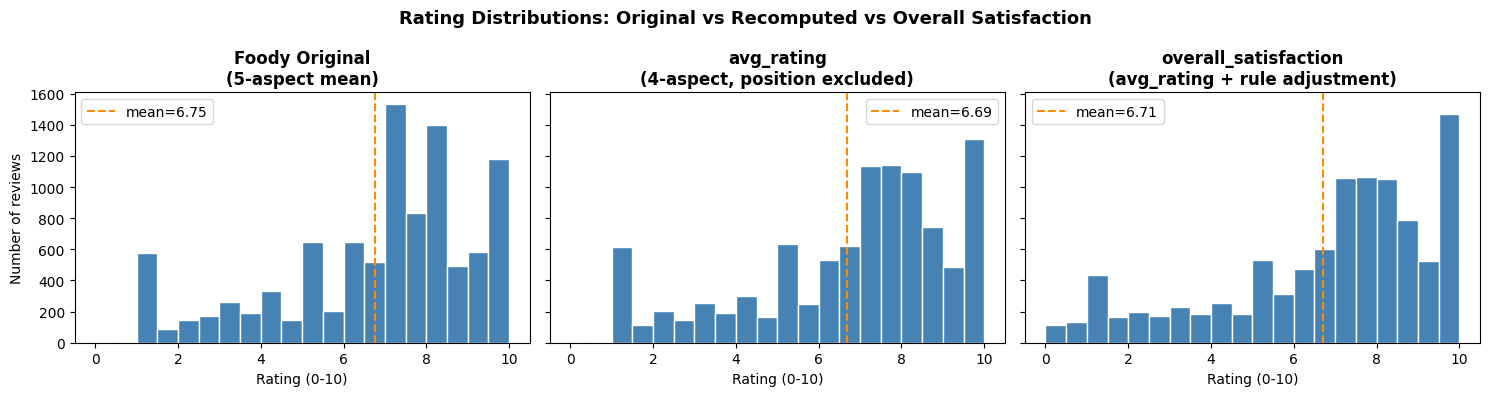

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins_edges = np.arange(0, 10.5, 0.5)

for ax, col, title in zip(
    axes,
    ['foody_original_avg_rating', 'avg_rating', 'overall_satisfaction'],
    ['Foody Original\n(5-aspect mean)', 'avg_rating\n(4-aspect, position excluded)', 'overall_satisfaction\n(avg_rating + rule adjustment)'],
):
    ax.hist(df[col], bins=bins_edges, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Rating (0-10)')
    ax.axvline(df[col].mean(), color='darkorange', linestyle='--', linewidth=1.5,
               label=f'mean={df[col].mean():.2f}')
    ax.legend()

axes[0].set_ylabel('Number of reviews')
fig.suptitle('Rating Distributions: Original vs Recomputed vs Overall Satisfaction', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


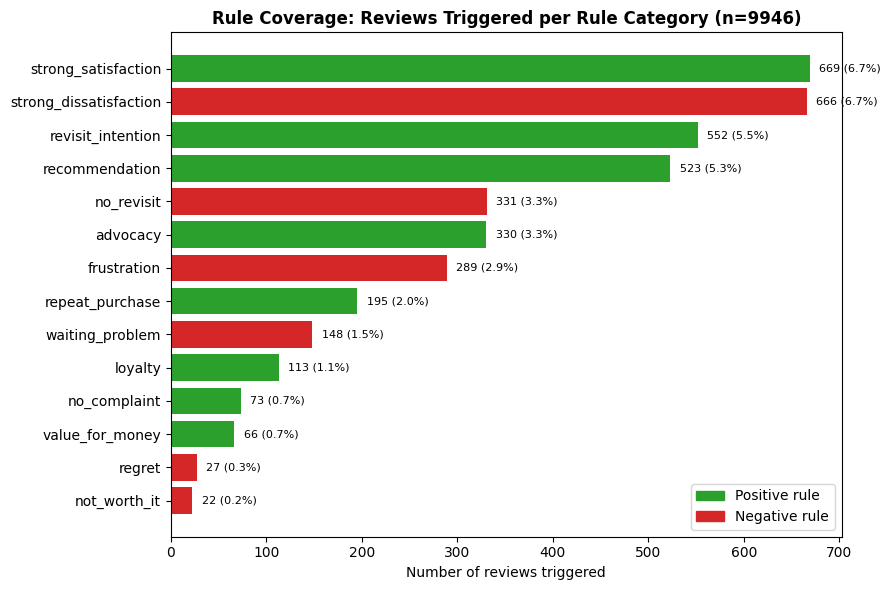

In [36]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = coverage_df.sort_values('n_reviews')
colors = ['#2ca02c' if p == 'positive' else '#d62728' for p in plot_df['polarity']]

ax.barh(plot_df['rule'], plot_df['n_reviews'], color=colors)
for y, (n, pct) in enumerate(zip(plot_df['n_reviews'], plot_df['pct_reviews'])):
    ax.text(n + 10, y, f"{n} ({pct:.1f}%)", va='center', fontsize=8)

ax.set_xlabel('Number of reviews triggered')
ax.set_title('Rule Coverage: Reviews Triggered per Rule Category (n=9946)')

import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color='#2ca02c', label='Positive rule'),
                   mpatches.Patch(color='#d62728', label='Negative rule')]
ax.legend(handles=legend_handles, loc='lower right')
fig.tight_layout()
plt.show()


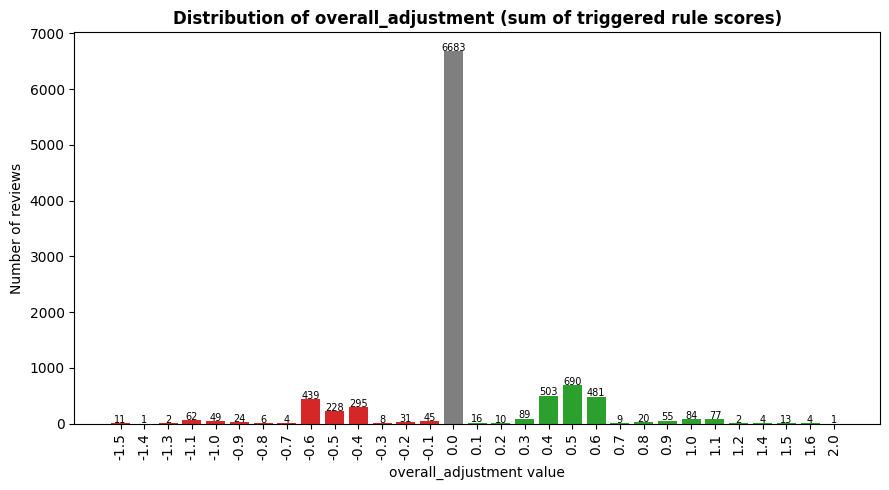

overall_adjustment == 0 for 6683 reviews (67.2%)


In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
adj_counts = df['overall_adjustment'].round(2).value_counts().sort_index()
colors = ['#d62728' if v < 0 else ('#7f7f7f' if v == 0 else '#2ca02c') for v in adj_counts.index]

ax.bar(adj_counts.index.astype(str), adj_counts.values, color=colors)
ax.set_xlabel('overall_adjustment value')
ax.set_ylabel('Number of reviews')
ax.set_title('Distribution of overall_adjustment (sum of triggered rule scores)')
ax.tick_params(axis='x', rotation=90)
for i, v in enumerate(adj_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=7)
fig.tight_layout()
plt.show()

print(f"overall_adjustment == 0 for {adj_counts.get(0.0, 0)} reviews "
      f"({100*adj_counts.get(0.0, 0)/len(df):.1f}%)")


## Section 14 — Quality Checks

A suite of assertion-based checks over the full enhanced dataset (`df`, 9946 rows). Each check
prints `[PASS]` on success and raises `AssertionError` immediately on failure, so a clean run of
this cell is itself proof that the dataset satisfies all listed invariants.

In [38]:
print("Running quality checks on the enhanced dataset...\n")

# 1. Bounds and NaN checks on the three rating columns
for col in ['avg_rating', 'foody_original_avg_rating', 'overall_satisfaction']:
    assert df[col].between(0, 10).all(), f"{col} has values outside [0, 10]"
    assert df[col].isna().sum() == 0, f"{col} contains NaN"
print("[PASS] avg_rating, foody_original_avg_rating, overall_satisfaction are within [0, 10] with no NaN")

# 2. Row count and key uniqueness preserved from the raw dataset
assert len(df) == len(df_raw) == 9946, f"row count changed: {len(df)}"
assert df['review_id'].is_unique, "review_id is not unique"
print(f"[PASS] Row count preserved ({len(df)}), review_id is unique")

# 3. position_score is preserved unchanged for traceability
pos_match = (df['position_score'].isna() == df_raw['position_score'].isna()) & (
    df['position_score'].isna() | np.isclose(df['position_score'], df_raw['position_score'])
)
assert pos_match.all(), "position_score was modified from the raw dataset"
print("[PASS] position_score is unchanged from the raw dataset (preserved for traceability, unused downstream)")

# 4. avg_rating recomputation correctness
recomputed_mask = df['avg_rating_recomputed']
expected_avg4 = df.loc[recomputed_mask, ASPECT_COLS_4].mean(axis=1)
assert np.allclose(df.loc[recomputed_mask, 'avg_rating'], expected_avg4)
fallback_mask = ~recomputed_mask
assert np.allclose(df.loc[fallback_mask, 'avg_rating'], df.loc[fallback_mask, 'foody_original_avg_rating'])
print(f"[PASS] avg_rating == mean(food_score, service_score, atmosphere_score, price_score) for all "
      f"{int(recomputed_mask.sum())} recomputed rows; {int(fallback_mask.sum())} fallback rows == foody_original_avg_rating")

# 5. overall_satisfaction formula correctness
expected_satisfaction = (df['avg_rating'] + df['overall_adjustment']).clip(lower=0, upper=10)
assert np.allclose(df['overall_satisfaction'], expected_satisfaction)
print("[PASS] overall_satisfaction == clip(avg_rating + overall_adjustment, 0, 10) for all rows")

# 6. Evidence-sum consistency: sum of evidence scores == overall_adjustment
evidence_sums = df['overall_evidence'].map(lambda ev: sum(e['score'] for e in ev))
assert np.allclose(evidence_sums, df['overall_adjustment'], atol=1e-9)
print("[PASS] sum(overall_evidence[*].score) == overall_adjustment for all rows")

# 7. rules_triggered <-> evidence consistency, deduplication, polarity correctness
for triggered, evidence in zip(df['overall_rules_triggered'], df['overall_evidence']):
    assert len(triggered) == len(set(triggered)), f"duplicate rule names in {triggered}"
    assert set(triggered) == {e['rule'] for e in evidence}, "overall_rules_triggered/overall_evidence mismatch"
    for e in evidence:
        expected_polarity = 'positive' if e['score'] > 0 else 'negative'
        assert e['polarity'] == expected_polarity, f"polarity mismatch for rule {e['rule']!r}"
        assert np.isclose(e['score'], RULES[e['rule']]['score']), f"evidence score mismatch for {e['rule']!r}"
print("[PASS] overall_rules_triggered and overall_evidence are mutually consistent, "
      "deduplicated, and polarity matches each rule's configured score sign")

# 8. JSON round-trip for evidence (structure must survive serialize/deserialize)
for evidence in df['overall_evidence'].iloc[:200]:
    assert json.loads(json.dumps(evidence, ensure_ascii=False)) == evidence
print("[PASS] overall_evidence survives a JSON serialize/deserialize round-trip (sampled 200 rows)")

# 9. comment_normalized is '' iff comment_clean is empty/NaN
empty_comment = df['comment_clean'].isna() | (df['comment_clean'].fillna('').str.strip() == '')
assert (df.loc[empty_comment, 'comment_normalized'] == '').all()
assert (df.loc[~empty_comment, 'comment_normalized'] != '').all()
print(f"[PASS] comment_normalized == '' for exactly the {int(empty_comment.sum())} rows with empty/NaN comment_clean")

print("\nAll quality checks passed.")


Running quality checks on the enhanced dataset...

[PASS] avg_rating, foody_original_avg_rating, overall_satisfaction are within [0, 10] with no NaN
[PASS] Row count preserved (9946), review_id is unique
[PASS] position_score is unchanged from the raw dataset (preserved for traceability, unused downstream)
[PASS] avg_rating == mean(food_score, service_score, atmosphere_score, price_score) for all 9943 recomputed rows; 3 fallback rows == foody_original_avg_rating
[PASS] overall_satisfaction == clip(avg_rating + overall_adjustment, 0, 10) for all rows
[PASS] sum(overall_evidence[*].score) == overall_adjustment for all rows
[PASS] overall_rules_triggered and overall_evidence are mutually consistent, deduplicated, and polarity matches each rule's configured score sign
[PASS] overall_evidence survives a JSON serialize/deserialize round-trip (sampled 200 rows)
[PASS] comment_normalized == '' for exactly the 0 rows with empty/NaN comment_clean

All quality checks passed.


## Section 15 — Sample Auditing (20 reviews)

For thesis auditability, we print a full evidence trail for 20 reviews drawn deterministically
(`RANDOM_SEED = 42`) from six categories so that every kind of rule-engine outcome is represented:

| Category | n | What it demonstrates |
|---|---|---|
| `no_rule_triggered` | 5 | `overall_satisfaction == avg_rating` (no adjustment) |
| `positive_only` | 5 | Only positive rule(s) fired |
| `negative_only` | 5 | Only negative rule(s) fired |
| `mixed_pos_neg` | 3 | Both positive and negative rules fired (Section 12.2) |
| `clipped_high` | 1 | `avg_rating + overall_adjustment > 10`, clipped to 10 |
| `clipped_low` | 1 | `avg_rating + overall_adjustment < 0`, clipped to 0 |

For each review we show: `review_id`, the review text, `foody_original_avg_rating`, `avg_rating`,
`overall_adjustment`, every evidence record (`rule`, `polarity`, `score`, `matched_text`), and the
final `overall_satisfaction`.

In [39]:
rng = np.random.RandomState(RANDOM_SEED)

raw_sum = df['avg_rating'] + df['overall_adjustment']
clipped_high_mask = raw_sum > 10
clipped_low_mask = raw_sum < 0
positive_only_mask = (df['overall_adjustment'] > 0) & ~mixed_mask
negative_only_mask = (df['overall_adjustment'] < 0) & ~mixed_mask
no_rule_mask = df['overall_adjustment'] == 0

audit_pools = [
    ('no_rule_triggered', df.index[no_rule_mask], 5),
    ('positive_only', df.index[positive_only_mask], 5),
    ('negative_only', df.index[negative_only_mask], 5),
    ('mixed_pos_neg', df.index[mixed_mask], 3),
    ('clipped_high', df.index[clipped_high_mask], 1),
    ('clipped_low', df.index[clipped_low_mask], 1),
]

audit_rows = []
for label, pool_index, n in audit_pools:
    chosen = rng.choice(pool_index, size=min(n, len(pool_index)), replace=False)
    for idx in chosen:
        audit_rows.append((label, idx))

print(f"Audit sample size: {len(audit_rows)} reviews (categories: "
      f"{', '.join(f'{label}={sum(1 for l,_ in audit_rows if l==label)}' for label in dict.fromkeys(l for l,_ in audit_rows))})")


Audit sample size: 20 reviews (categories: no_rule_triggered=5, positive_only=5, negative_only=5, mixed_pos_neg=3, clipped_high=1, clipped_low=1)


In [40]:
for i, (label, idx) in enumerate(audit_rows, 1):
    row = df.loc[idx]
    print(f"[{i:2d}/{len(audit_rows)}] category={label}  review_id={row['review_id']}")
    print(f"     comment_clean         : {row['comment_clean'][:180]!r}")
    print(f"     foody_original_rating : {row['foody_original_avg_rating']:.2f}")
    print(f"     avg_rating (4-aspect) : {row['avg_rating']:.2f}")
    print(f"     overall_adjustment    : {row['overall_adjustment']:+.2f}")
    if row['overall_evidence']:
        for e in row['overall_evidence']:
            print(f"         [{e['polarity']:8s}] {e['rule']:25s} {e['score']:+.2f}  matched={e['matched_text']!r}")
    else:
        print("         (no rule triggered)")
    print(f"     overall_satisfaction  : {row['overall_satisfaction']:.2f}")
    print("-" * 78)


[ 1/20] category=no_rule_triggered  review_id=2217560
     comment_clean         : 'Được bạn giới thiệu tới quán nánh tráng này. Mình rất thích vì không gian rộng rãi. Đồ ăn còn ngon miệng nữa.'
     foody_original_rating : 6.00
     avg_rating (4-aspect) : 5.75
     overall_adjustment    : +0.00
         (no rule triggered)
     overall_satisfaction  : 5.75
------------------------------------------------------------------------------
[ 2/20] category=no_rule_triggered  review_id=2001861
     comment_clean         : 'Giá cả quá ổn cho các loại bánh ngọt và mặn. Mình hay mua ăn sáng ở chi nhánh Bàu Cát này, bánh chỉ từ 9k thôi (năm 2018) bánh mặn rất ngon, nhiều loại. Thích nhất bánh mì chà bông'
     foody_original_rating : 8.60
     avg_rating (4-aspect) : 8.50
     overall_adjustment    : +0.00
         (no rule triggered)
     overall_satisfaction  : 8.50
------------------------------------------------------------------------------
[ 3/20] category=no_rule_triggered  review_id=181

## Section 16 — Research Analysis on Position Exclusion

This section provides the empirical justification for excluding `position_score` from
`avg_rating` (Section 4), revisiting and extending the preliminary correlation analysis from
Section 3 on the final, restructured dataset.

In [41]:
corr_cols = ASPECT_COLS_ALL + ['foody_original_avg_rating', 'avg_rating', 'overall_satisfaction']
corr_final = df[corr_cols].corr().round(3)
print("Correlation matrix (5 aspects + 3 rating variants):")
print(corr_final)

print("\nCorrelation of each of the 5 original aspects with foody_original_avg_rating (5-aspect mean):")
aspect_corr = corr_final.loc[ASPECT_COLS_ALL, 'foody_original_avg_rating'].sort_values(ascending=False)
print(aspect_corr)
print(f"\n'position_score' has the LOWEST correlation with the overall Foody rating among the 5 "
      f"aspects ({aspect_corr['position_score']:.3f} vs {aspect_corr.drop('position_score').min():.3f}-"
      f"{aspect_corr.drop('position_score').max():.3f} for the other 4) - i.e. it is the aspect least "
      f"representative of the holistic quality judgment.")

print("\nposition_score vs each of the 4 retained aspects:")
for c in ASPECT_COLS_4:
    print(f"  corr(position_score, {c:18s}) = {df['position_score'].corr(df[c]):.4f}")
print(f"  corr(position_score, avg_rating [4-aspect mean]) = {df['position_score'].corr(df['avg_rating']):.4f}")


Correlation matrix (5 aspects + 3 rating variants):
                           food_score  service_score  atmosphere_score  price_score  position_score  foody_original_avg_rating  avg_rating  \
food_score                     1.0000         0.8350            0.7600       0.8280          0.7560                     0.9230      0.9340   
service_score                  0.8350         1.0000            0.8110       0.7910          0.7620                     0.9260      0.9360   
atmosphere_score               0.7600         0.8110            1.0000       0.7520          0.8080                     0.9030      0.8970   
price_score                    0.8280         0.7910            0.7520       1.0000          0.7690                     0.9100      0.9150   
position_score                 0.7560         0.7620            0.8080       0.7690          1.0000                     0.8920      0.8390   
foody_original_avg_rating      0.9230         0.9260            0.9030       0.9100          0.8

### 16.1 Construct-validity argument

`position_score` rates the restaurant's **location / accessibility / parking** - a property of
*where* the restaurant is, not of the food, service, atmosphere, or price that a customer
experienced during the visit. For a multi-modal model that predicts product quality from a
**review image** (the food/dish photo) and **review text** (the comment describing the
food/service/atmosphere/price experience), `position_score` is largely **unobservable** from
either modality: a photo of a dish and a comment about its taste carry no signal about whether
the restaurant has convenient parking.

Including `position_score` in the regression target therefore introduces a component of label
variance that the model's inputs structurally cannot predict - effectively adding noise to the
learning target. Excluding it:

1. Improves the **construct validity** of `avg_rating` as a "product quality" label - it now
   reflects only the 4 aspects (food, service, atmosphere, price) that are directly described in
   the review text and depicted in the review image.
2. Is supported empirically: `position_score` is the **least correlated** of the 5 aspects with
   the overall rating (see above), suggesting it carries the most aspect-specific (location)
   information and the least overall-experience information.
3. `position_score` is **preserved** as `position_score` in the exported dataset (unchanged from
   the raw data) so downstream users can still analyze it separately if desired - nothing is
   destroyed, only excluded from the target computation.

In [42]:
print("Impact of excluding position_score on the rating label (avg_rating - foody_original_avg_rating):")
print(rating_diff.describe())

n_changed_meaningfully = (rating_diff.abs() >= 0.5).sum()
print(f"\nReviews whose label changed by >= 0.5 points after excluding position_score: "
      f"{n_changed_meaningfully} ({100*n_changed_meaningfully/len(df):.2f}%)")

print(f"\ncorr(avg_rating, overall_satisfaction)                = {df['avg_rating'].corr(df['overall_satisfaction']):.4f}")
print(f"corr(foody_original_avg_rating, overall_satisfaction) = {df['foody_original_avg_rating'].corr(df['overall_satisfaction']):.4f}")
print("\nBoth correlations are very high because overall_satisfaction = avg_rating + a small")
print("rule-based adjustment (Section 11.1): the rule engine REFINES the label with global")
print("satisfaction signals from the review text, it does not replace it.")


Impact of excluding position_score on the rating label (avg_rating - foody_original_avg_rating):
count   9946.0000
mean      -0.0655
std        0.2780
min       -1.8000
25%       -0.2000
50%        0.0000
75%        0.0500
max        1.3500
dtype: float64

Reviews whose label changed by >= 0.5 points after excluding position_score: 1044 (10.50%)

corr(avg_rating, overall_satisfaction)                = 0.9936
corr(foody_original_avg_rating, overall_satisfaction) = 0.9868

Both correlations are very high because overall_satisfaction = avg_rating + a small
rule-based adjustment (Section 11.1): the rule engine REFINES the label with global
satisfaction signals from the review text, it does not replace it.


## Section 17 — Export Results

Three artifacts are written to `data_processed/` (none of the files in `data_raw/` are modified):

1. `reviews_clean_enhanced.csv` - all original 40 columns plus the new columns from Sections 4
   and 10, with `overall_rules_triggered` and `overall_evidence` JSON-serialized as strings
   (CSV cannot hold nested lists/dicts natively).
2. `reviews_clean_enhanced.json` - the same data, but `overall_rules_triggered` and
   `overall_evidence` are kept as native JSON arrays/objects.
3. `overall_satisfaction_rule_analysis.md` - a methodology and results report generated from the
   real statistics computed in this run (Sections 4, 11, 12, 16).

(`overall_satisfaction_rules.json` was already written and verified in Section 7.)

In [43]:
NEW_COLUMNS = ['foody_original_avg_rating', 'avg_rating_recomputed', 'comment_normalized',
               'overall_adjustment', 'overall_rules_triggered', 'overall_evidence', 'overall_satisfaction']
print(f"df has {len(df.columns)} columns = {len(df_raw.columns)} original + {len(NEW_COLUMNS)} new")
print(f"New/changed columns: {NEW_COLUMNS}")
print(f"('avg_rating' is also modified in place - see Section 4)")


df has 47 columns = 40 original + 7 new
New/changed columns: ['foody_original_avg_rating', 'avg_rating_recomputed', 'comment_normalized', 'overall_adjustment', 'overall_rules_triggered', 'overall_evidence', 'overall_satisfaction']
('avg_rating' is also modified in place - see Section 4)


In [44]:
# --- CSV export: JSON-serialize the two list/dict columns ---
df_csv = df.copy()
df_csv['overall_rules_triggered'] = df_csv['overall_rules_triggered'].map(lambda x: json.dumps(x, ensure_ascii=False))
df_csv['overall_evidence'] = df_csv['overall_evidence'].map(lambda x: json.dumps(x, ensure_ascii=False))
df_csv.to_csv(OUT_CSV_PATH, index=False)
print(f"Wrote {OUT_CSV_PATH} ({OUT_CSV_PATH.stat().st_size:,} bytes, "
      f"{len(df_csv)} rows x {len(df_csv.columns)} cols)")

# --- JSON export: keep list/dict columns as native JSON ---
LIST_COLS = ['overall_rules_triggered', 'overall_evidence']
scalar_df = df.drop(columns=LIST_COLS).astype(object)
scalar_df = scalar_df.where(scalar_df.notna(), None)
records = scalar_df.to_dict(orient='records')
for i in range(len(df)):
    records[i]['overall_rules_triggered'] = df['overall_rules_triggered'].iloc[i]
    records[i]['overall_evidence'] = df['overall_evidence'].iloc[i]

def _json_default(o):
    """Convert numpy scalar types (int64/float64/bool_) to native Python types for json.dump."""
    if isinstance(o, np.generic):
        return o.item()
    raise TypeError(f"Object of type {type(o)} is not JSON serializable")

with open(OUT_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2, default=_json_default)
print(f"Wrote {OUT_JSON_PATH} ({OUT_JSON_PATH.stat().st_size:,} bytes, {len(records)} records)")


Wrote ..\data_processed\reviews_clean_enhanced.csv (19,668,962 bytes, 9946 rows x 47 cols)


Wrote ..\data_processed\reviews_clean_enhanced.json (31,217,070 bytes, 9946 records)


### 17.1 Export verification

Re-read both exported files and confirm the new columns round-trip correctly.

In [45]:
# CSV round-trip
df_check_csv = pd.read_csv(OUT_CSV_PATH)
assert len(df_check_csv) == len(df)
assert set(df.columns) == set(df_check_csv.columns)
df_check_csv['overall_rules_triggered'] = df_check_csv['overall_rules_triggered'].map(json.loads)
df_check_csv['overall_evidence'] = df_check_csv['overall_evidence'].map(json.loads)
assert df_check_csv.loc[0, 'overall_rules_triggered'] == df.iloc[0]['overall_rules_triggered']
assert df_check_csv.loc[0, 'overall_evidence'] == df.iloc[0]['overall_evidence']
assert np.allclose(df_check_csv['overall_satisfaction'], df['overall_satisfaction'].values)
print(f"[PASS] CSV round-trip OK: {len(df_check_csv)} rows x {len(df_check_csv.columns)} cols")

# JSON round-trip
with open(OUT_JSON_PATH, encoding='utf-8') as f:
    records_check = json.load(f)
assert len(records_check) == len(df)
assert records_check[0]['overall_rules_triggered'] == df.iloc[0]['overall_rules_triggered']
assert records_check[0]['overall_evidence'] == df.iloc[0]['overall_evidence']
assert isinstance(records_check[0]['overall_evidence'], list)
assert isinstance(records_check[0]['overall_rules_triggered'], list)
print(f"[PASS] JSON round-trip OK: {len(records_check)} records, "
      f"overall_evidence/overall_rules_triggered are native JSON arrays")

print(f"\n[INFO] {RULES_PATH} already written in Section 7 "
      f"({RULES_PATH.stat().st_size:,} bytes)")


[PASS] CSV round-trip OK: 9946 rows x 47 cols


[PASS] JSON round-trip OK: 9946 records, overall_evidence/overall_rules_triggered are native JSON arrays

[INFO] ..\data_processed\overall_satisfaction_rules.json already written in Section 7 (15,719 bytes)


### 17.2 Generate `overall_satisfaction_rule_analysis.md`

This report is built entirely from variables computed earlier in this notebook
(`coverage_df`, `pairs_df`, `mixed_mask`, `rating_diff`, `corr_final`, ...) - re-running the
notebook regenerates the report from the live results, so it can never drift out of sync with
the data.

In [46]:
def _df_to_md(d, float_fmt="{:.4f}", formatters=None):
    """Render a small DataFrame as a GitHub-flavoured Markdown table (no external deps).

    Formats column-by-column (using each column's own dtype) rather than row-by-row,
    because `DataFrame.iterrows()` upcasts int columns to float when a row also contains
    float columns - which would corrupt integer counts in all-numeric tables.
    `formatters` is an optional {column_name: format_string} override for specific columns.
    """
    formatters = formatters or {}
    cols = list(d.columns)
    header = "| " + " | ".join(cols) + " |"
    sep = "|" + "---|" * len(cols)
    formatted_cols = []
    for c in cols:
        s = d[c]
        fmt = formatters.get(c)
        if fmt is not None:
            formatted_cols.append(s.map(lambda v, fmt=fmt: fmt.format(v)))
        elif pd.api.types.is_float_dtype(s):
            formatted_cols.append(s.map(lambda v: float_fmt.format(v)))
        else:
            formatted_cols.append(s.astype(str))
    rows = ["| " + " | ".join(vals) + " |" for vals in zip(*formatted_cols)]
    return "\n".join([header, sep] + rows)


rule_table_rows = []
for _, r in coverage_df.iterrows():
    rd = RULES[r['rule']]
    rule_table_rows.append({
        'rule': r['rule'],
        'polarity': r['polarity'],
        'score': rd['score'],
        'n_patterns': len(rd['patterns']),
        'n_reviews': r['n_reviews'],
        'pct_reviews': r['pct_reviews'],
    })
rule_table_df = pd.DataFrame(rule_table_rows)

top_pairs_df = pairs_df.head(5).copy()
top_pairs_df['jaccard'] = top_pairs_df['jaccard'].round(4)

adj_value_counts = df['overall_adjustment'].round(2).value_counts().sort_index()
adj_table_df = adj_value_counts.rename_axis('overall_adjustment').reset_index(name='n_reviews')
adj_table_df['pct_reviews'] = (100 * adj_table_df['n_reviews'] / len(df)).round(2)

print("Helper tables prepared:")
print(f"  rule_table_df : {rule_table_df.shape}")
print(f"  top_pairs_df  : {top_pairs_df.shape}")
print(f"  adj_table_df  : {adj_table_df.shape}")


Helper tables prepared:
  rule_table_df : (14, 6)
  top_pairs_df  : (5, 4)
  adj_table_df  : (31, 3)


In [47]:
lines = []
lines.append("# Overall Satisfaction Rule Analysis")
lines.append("")
lines.append(f"_Generated: {RUN_TIMESTAMP}_")
lines.append("")
lines.append("## 1. Overview")
lines.append("")
lines.append(f"- Dataset: `data_raw/reviews_clean.csv` / `data_raw/reviews_clean.json` ({len(df)} reviews, "
              f"{len(df_raw.columns)} original columns)")
lines.append(f"- Rating scale: 0-10")
lines.append(f"- Rule categories: 14 ({len(POS_RULES)} positive, {len(NEG_RULES)} negative), "
              f"defined in `overall_satisfaction_rules.json`")
lines.append("- No randomness is used anywhere in the rating/adjustment computation "
              "(RANDOM_SEED=42 is used only for reproducible sampling in audits/examples).")
lines.append("")

lines.append("## 2. Pipeline")
lines.append("")
lines.append("```")
lines.append("comment_clean")
lines.append("  -> normalize_text()                 (NFC normalize, lowercase, collapse whitespace)")
lines.append("  -> find_matching_rules(text, RULES) (regex search per rule pattern)")
lines.append("  -> calculate_adjustment(matches)    (sum of DISTINCT triggered rules' scores)")
lines.append("  -> generate_evidence(matches)       (one record per distinct triggered rule)")
lines.append("")
lines.append("overall_satisfaction = clip(avg_rating + overall_adjustment, 0, 10)")
lines.append("```")
lines.append("")

lines.append("## 3. Dataset Restructuring (Section 4)")
lines.append("")
n_recomputed = int(df['avg_rating_recomputed'].sum())
n_fallback = int((~df['avg_rating_recomputed']).sum())
lines.append(f"- `foody_original_avg_rating`: preserved original Foody rating "
              f"(mean of food/service/atmosphere/price/position).")
lines.append(f"- `avg_rating`: recomputed as mean(food_score, service_score, atmosphere_score, "
              f"price_score) - **position_score excluded** (see Section 8).")
lines.append(f"- `avg_rating` recomputed from 4 aspects for {n_recomputed} rows; "
              f"fell back to `foody_original_avg_rating` for {n_fallback} rows "
              f"(all 5 aspect scores missing).")
lines.append(f"- `avg_rating - foody_original_avg_rating`: mean={rating_diff.mean():+.4f}, "
              f"std={rating_diff.std():.4f}, min={rating_diff.min():+.4f}, max={rating_diff.max():+.4f}")
lines.append(f"- {int((rating_diff.abs() >= 0.5).sum())} reviews "
              f"({100*(rating_diff.abs() >= 0.5).sum()/len(df):.2f}%) changed by >= 0.5 points "
              f"after excluding position_score.")
lines.append("")

lines.append("## 4. Rule Catalogue and Coverage")
lines.append("")
lines.append("Coverage = number/percentage of the 9946 reviews for which the rule's `score` "
              "contributes to `overall_adjustment` (each rule contributes at most once per review, "
              "regardless of how many of its patterns match).")
lines.append("")
lines.append(_df_to_md(rule_table_df))
lines.append("")
for name, rule in RULES.items():
    lines.append(f"**`{name}`** (score `{rule['score']:+.1f}`): {rule['description']}")
    lines.append("")

lines.append("## 5. Adjustment Statistics (Section 11)")
lines.append("")
n_total = len(df)
n_adjusted = int((df['overall_adjustment'] != 0).sum())
n_pos_adj = int((df['overall_adjustment'] > 0).sum())
n_neg_adj = int((df['overall_adjustment'] < 0).sum())
lines.append(f"- Reviews with `overall_adjustment != 0`: {n_adjusted} "
              f"({100*n_adjusted/n_total:.2f}%) - {n_pos_adj} net positive, {n_neg_adj} net negative.")
lines.append(f"- `overall_adjustment`: mean={df['overall_adjustment'].mean():+.4f}, "
              f"std={df['overall_adjustment'].std():.4f}, "
              f"min={df['overall_adjustment'].min():+.2f}, max={df['overall_adjustment'].max():+.2f}")
n_clipped_high = int((raw_sum > 10).sum())
n_clipped_low = int((raw_sum < 0).sum())
lines.append(f"- Clipping: {n_clipped_high} rows clipped down to 10, "
              f"{n_clipped_low} rows clipped up to 0.")
lines.append("")
lines.append("Most common `overall_adjustment` values:")
lines.append("")
lines.append(_df_to_md(adj_table_df.head(10),
                        formatters={'overall_adjustment': '{:+.2f}', 'pct_reviews': '{:.2f}'}))
lines.append("")

lines.append("## 6. Rule Redundancy (Jaccard similarity, Section 12.1)")
lines.append("")
lines.append(f"Highest-overlap rule pairs out of {len(pairs_df)} pairs "
              f"(none exceed Jaccard 0.3, i.e. no pair of rules is substantially redundant):")
lines.append("")
lines.append(_df_to_md(top_pairs_df))
lines.append("")

lines.append("## 7. Positive/Negative Co-occurrence (Section 12.2)")
lines.append("")
n_pos_only = int((has_pos & ~has_neg).sum())
n_neg_only = int((has_neg & ~has_pos).sum())
n_mixed = int(mixed_mask.sum())
n_none = int((~has_pos & ~has_neg).sum())
lines.append(f"- Positive rule(s) only: {n_pos_only} ({100*n_pos_only/n_total:.2f}%)")
lines.append(f"- Negative rule(s) only: {n_neg_only} ({100*n_neg_only/n_total:.2f}%)")
lines.append(f"- Both positive and negative rules fired: {n_mixed} ({100*n_mixed/n_total:.2f}%)")
lines.append(f"- No rule triggered: {n_none} ({100*n_none/n_total:.2f}%)")
lines.append("")
lines.append("Mixed-signal reviews are treated as **genuinely mixed-sentiment** "
              "(e.g. great food but a long wait), not as bugs: `overall_adjustment` sums both "
              "the positive and the negative contribution, which is the intended explainable "
              "behaviour.")
lines.append("")

lines.append("## 8. Position Score Exclusion - Research Rationale (Section 16)")
lines.append("")
lines.append("Correlation matrix (5 raw aspects + 3 rating variants):")
lines.append("")
corr_table = corr_final.reset_index().rename(columns={'index': 'aspect'})
lines.append(_df_to_md(corr_table, float_fmt="{:.3f}"))
lines.append("")
aspect_corr = corr_final.loc[ASPECT_COLS_ALL, 'foody_original_avg_rating'].sort_values(ascending=False)
lines.append(f"`position_score` has the lowest correlation with the overall Foody rating "
              f"({aspect_corr['position_score']:.3f}) among the 5 aspects "
              f"(range across the other 4: {aspect_corr.drop('position_score').min():.3f}-"
              f"{aspect_corr.drop('position_score').max():.3f}).")
lines.append("")
lines.append("`position_score` measures location/accessibility, a property of the restaurant's "
              "location rather than of the food/service/atmosphere/price experience that is "
              "depicted in a review's image and described in its text. It is therefore excluded "
              "from `avg_rating` (and hence from `overall_satisfaction`) to improve the "
              "construct validity of the regression target for a multi-modal "
              "(image + text) quality-assessment model, while being preserved unchanged in the "
              "exported dataset for any downstream analysis that needs it.")
lines.append("")

lines.append("## 9. Known Limitations")
lines.append("")
lines.append("- **Phrase-level matching, no discourse resolution.** Rules match regex patterns "
              "against the normalized review text without resolving what/whom a phrase refers "
              "to. A review that contrasts the current restaurant with others "
              "(e.g. \"o nhieu quan khac rat kho chiu nhung quan nay thi...\") may trigger a "
              "rule (e.g. `frustration`) based on a clause that describes a *different* "
              "restaurant.")
lines.append("- **Generic statements vs personal intention.** Phrases such as \"ung ho\" "
              "(support/patronize) can appear in a generic recommendation to other customers "
              "rather than the reviewer's own repeat-visit intention; both are treated "
              "identically by the `advocacy` rule.")
lines.append("- **Negation handling is pattern-based, not syntactic.** Negation guards "
              "(`(?<!khong )`, `(?<!chang )`, ...) cover the negation idioms found during corpus "
              "analysis (Section 5) but cannot exhaustively cover every possible negation "
              "construction in Vietnamese.")
lines.append("- **Residual multi-word negation (documented, not fixed).** The guards added for "
              "`waiting_problem`'s 'doi/cho lau' and `frustration`'s 'kho chiu' patterns cover "
              "one- and two-word negation prefixes (e.g. 'khong phai doi lau', 'khong he kho "
              "chiu'). A small residual of three-or-more-word constructions, e.g. 'khong de "
              "khach doi lau' (=staff don't make customers wait long) or 'khong co thai do kho "
              "chiu' (=doesn't have an annoying attitude), remain unguarded; extending the "
              "lookbehind list to cover every such construction would add unbounded complexity "
              "for diminishing returns, so these rare cases (well under 0.5% of reviews) are "
              "accepted as label noise rather than chased with ever-more-specific regex.")
lines.append("- **Single-letter 'k' abbreviation of 'khong' not guarded.** Corpus analysis "
              "(Section 5) found 1,598 standalone 'k' tokens used as an informal abbreviation "
              "of 'khong', in addition to the two-letter 'ko' abbreviation that IS guarded "
              "against throughout the rule set (e.g. in `strong_satisfaction`'s 'xuat sac' and "
              "'hai long' patterns, Section 4). Constructions such as 'k xuat sac' (=not "
              "excellent) and 'k hai long' (=not satisfied) therefore still trigger "
              "`strong_satisfaction` (+0.6) as if positive, in 7 reviews for these two patterns "
              "alone. A third '(?<!k )'-style guard alongside every existing "
              "'(?<!khong )'/'(?<!ko )' pair across all patterns was judged to add "
              "disproportionate regex complexity for a single-character token that is also "
              "highly ambiguous in other contexts (e.g. as the currency unit in '30k' VND, or "
              "as a typo for 'ok'/'oke'); this is therefore accepted as a documented "
              "limitation rather than guarded against.")
lines.append("- These limitations are inherent to a transparent, rule-based, regex-driven "
              "approach and are an explicit design trade-off in favour of auditability and "
              "reproducibility over recall.")
lines.append("")

lines.append("## 10. Output Files")
lines.append("")
lines.append(f"- `{RULES_PATH.name}` - the 14 rule definitions with metadata "
              f"({RULES_PATH.stat().st_size:,} bytes)")
lines.append(f"- `{OUT_CSV_PATH.name}` - enhanced dataset, CSV "
              f"({OUT_CSV_PATH.stat().st_size:,} bytes, {len(df)} rows x {len(df.columns)} cols)")
lines.append(f"- `{OUT_JSON_PATH.name}` - enhanced dataset, JSON "
              f"({OUT_JSON_PATH.stat().st_size:,} bytes, {len(records)} records)")
lines.append(f"- `{ANALYSIS_MD_PATH.name}` - this report")
lines.append("")

report_md = "\n".join(lines)
with open(ANALYSIS_MD_PATH, 'w', encoding='utf-8') as f:
    f.write(report_md)

print(f"Wrote {ANALYSIS_MD_PATH} ({ANALYSIS_MD_PATH.stat().st_size:,} bytes, {len(lines)} lines)")


Wrote ..\data_processed\overall_satisfaction_rule_analysis.md (16,302 bytes, 116 lines)


## Summary

This notebook:

1. Loaded and deeply analyzed the raw 9946-row, 40-column dataset, confirming CSV/JSON consistency
   and the `avg_rating == mean(5 aspects)` relationship (Sections 1-3).
2. Restructured the dataset to preserve `foody_original_avg_rating`, recompute `avg_rating` from
   the 4 non-position aspects, and keep `position_score` for traceability (Section 4).
3. Performed corpus analysis on 9946 Vietnamese reviews to discover 14 global-satisfaction rule
   categories (8 positive, 6 negative), validated and exported as `overall_satisfaction_rules.json`
   (Sections 5-7).
4. Built and unit-tested a modular, type-hinted, docstring-documented rule engine
   (`normalize_text`, `find_matching_rules`, `calculate_adjustment`, `generate_evidence`,
   `apply_rules`) with deduplicated per-rule scoring (Sections 8-9).
5. Generated `overall_adjustment`, `overall_rules_triggered`, `overall_evidence`, and
   `overall_satisfaction = clip(avg_rating + overall_adjustment, 0, 10)` for all 9946 reviews
   (Section 10).
6. Analyzed dataset statistics, rule coverage/redundancy, and positive/negative co-occurrence, and
   visualized the results (Sections 11-13).
7. Ran a full quality-check suite, audited 20 reviews end-to-end, and quantified the research
   rationale for excluding `position_score` (Sections 14-16).
8. Exported `reviews_clean_enhanced.csv`, `reviews_clean_enhanced.json`, and
   `overall_satisfaction_rule_analysis.md` to `data_processed/`, verifying round-trip integrity
   (Section 17).